This code implements an XGBoost regressor trained on the residuals of a previously predicted series to improve forecasting performance.

There are two data inputs: one containing the raw residuals of the already predicted series, and another containing the engineered exogenous variables.

The purpose of this code is not cleanliness but efficiency for strategic decision-making. As part of a portfolio, it is meant to be context-comprehensible rather than fully structured for strict replicability.

# 0) Setting Up Lab

In [ ]:
#start
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#machine learning
import xgboost as xgb
#analysis tools imports
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from scipy.stats import linregress, norm
from datetime import timedelta

#visualize
color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')

In [ ]:
from google.colab import files
import pandas as pd
import io

file_name = 'TargetXGB_scale.csv'

# Initialize 'uploaded' as an empty dictionary if it's not already defined
if 'uploaded' not in locals():
  uploaded = {}

if file_name not in uploaded:
  uploaded = files.upload()                 # will only ask once

df = pd.read_csv(io.BytesIO(uploaded[file_name]))
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
#display(df.head())

Saving TargetXGB_scale.csv to TargetXGB_scale.csv


# 1) Curate Dataset

# 1.0) Change index order (start from the first date) + Forward fil if needed
Dataset size => Forwardfill

In [ ]:
# Keep the original index name
date_name = df.index.name or 'date'
full_index = pd.date_range(df.index.min(), df.index.max(), freq='D')
df_ff = df.reindex(full_index).ffill()
df_ff.index.name = date_name

# Save dataset
output_name = 'TargetXGB_scale.csv'
df_ff.to_csv(output_name, index_label=date_name)

# Choose the first data column (replace with real name if needed)
col = df_ff.columns[0]
# Re-EDA
print("Shape after forward fill:", df_ff.shape)
print("\nMissing values per column:\n", df_ff.isna().sum())
print("\nDate range:", df_ff.index.min(), "to", df_ff.index.max())
print("\nSummary statistics:\n", df_ff.describe())


#Making sure my dataset is the size of the whole forward-filled year
df = df_ff
display(df)

Shape after forward fill: (3288, 1)

Missing values per column:
 TargetXGB_scale    0
dtype: int64

Date range: 2016-01-01 00:00:00 to 2024-12-31 00:00:00

Summary statistics:
        TargetXGB_scale
count      3288.000000
mean          0.842224
std         514.987794
min       -1325.688939
25%        -308.269974
50%        -103.454799
75%         261.960469
max        3659.090530


,TargetXGB_scale
date,
2016-01-01,-120.983909
2016-01-02,-0.581430
2016-01-03,136.177546
2016-01-04,360.280017
2016-01-05,-224.930599
...,...
2024-12-27,-459.423805
2024-12-28,-755.159526
2024-12-29,-265.189634


# 1.1) Ploting Mean/30 day Moving Avarage & Linear Trend for the curated dataset
(by year)

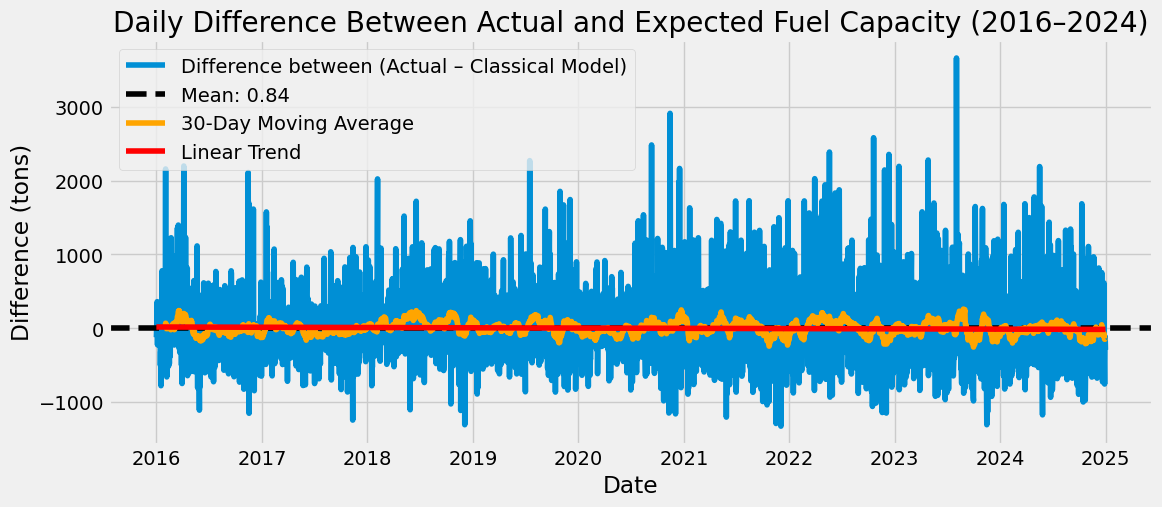

In [ ]:
# Plot full set mean + moving avarage
# Calculate the mean of the first column
mean_value = df.iloc[:, 0].mean()

# Calculate a 30-day rolling moving average
rolling_mean = df.iloc[:, 0].rolling(window=30).mean()

# Calculate the linear trend line
# We need numerical representation of dates for linregress
df['date_ordinal'] = df.index.map(pd.Timestamp.toordinal)
slope, intercept, r_value, p_value, std_err = linregress(df['date_ordinal'], df.iloc[:, 0])
trend_line = slope * df['date_ordinal'] + intercept

# Drop the 'date_ordinal' column after calculating the trend line
df = df.drop(columns=['date_ordinal'])

plt.figure(figsize=(12,5))
plt.plot(df.index, df.iloc[:,0], label="Difference between (Actual – Classical Model)")
plt.axhline(mean_value, color='black', linestyle='--', label=f'Mean: {mean_value:.2f}') # Add the mean line
plt.plot(df.index, rolling_mean, label='30-Day Moving Average', color='orange') # Add moving average
plt.plot(df.index, trend_line, label='Linear Trend', color='red', linestyle='-') # Add trend line

plt.title("Daily Difference Between Actual and Expected Fuel Capacity (2016–2024)")
plt.xlabel("Date")
plt.ylabel("Difference (tons)")
plt.legend()
plt.show()

# 2) Prep. Data

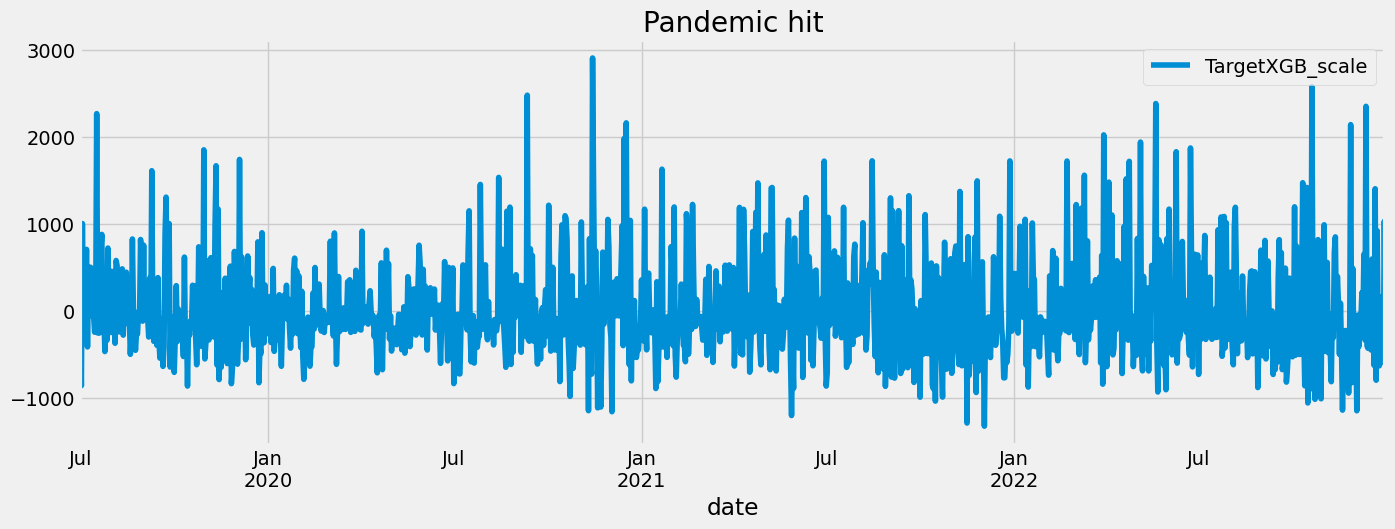

Shape of slice: (1280, 1)

Missing values per column in slice:
 TargetXGB_scale    0
dtype: int64

Date range of slice: 2019-07-01 00:00:00 to 2022-12-31 00:00:00

Summary statistics of slice:
        TargetXGB_scale
count      1280.000000
mean          2.421508
std         562.243890
min       -1325.688939
25%        -343.837113
50%        -119.175843
75%         295.031312
max        2909.779664


In [ ]:
# The df variable is already loaded and forward-filled from previous steps.
# This cell re-reads the original csv and overwrites the forward-filled dataframe.
df.index = pd.to_datetime(df.index)

#I can check one month length for different months
df_slice = df.loc['2019-07-01':'2022-12-31']
df_slice.plot(figsize=(15, 5), title='Pandemic hit') #this is the peak on July to October
plt.show()

# Perform EDA on the slice
print("Shape of slice:", df_slice.shape)
print("\nMissing values per column in slice:\n", df_slice.isna().sum())
print("\nDate range of slice:", df_slice.index.min(), "to", df_slice.index.max())
print("\nSummary statistics of slice:\n", df_slice.describe())

## 2.1) Whole Data Analysis for Outlier  removal

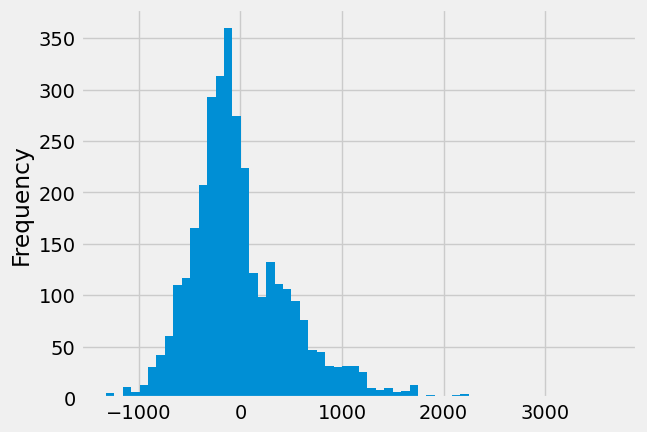

In [ ]:
df['TargetXGB_scale'].plot(kind='hist', bins=60)
plt.show()

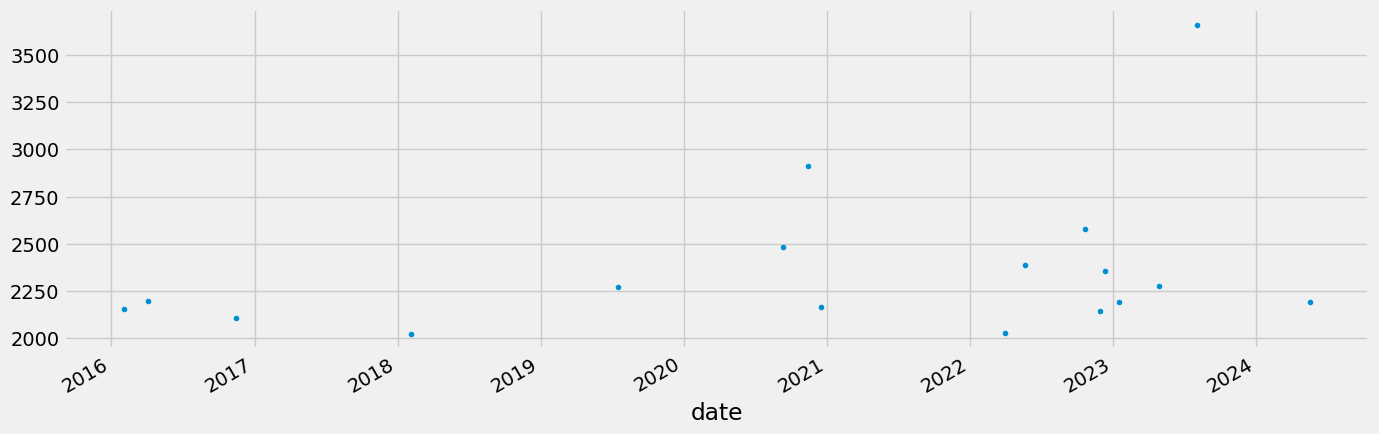

In [ ]:
df.query('TargetXGB_scale > 2000')['TargetXGB_scale'].plot(figsize=(15, 5), style='.')
plt.show()

### ------------------------ DECISION POINT ------------------------

## 2.2) Outlier Removal

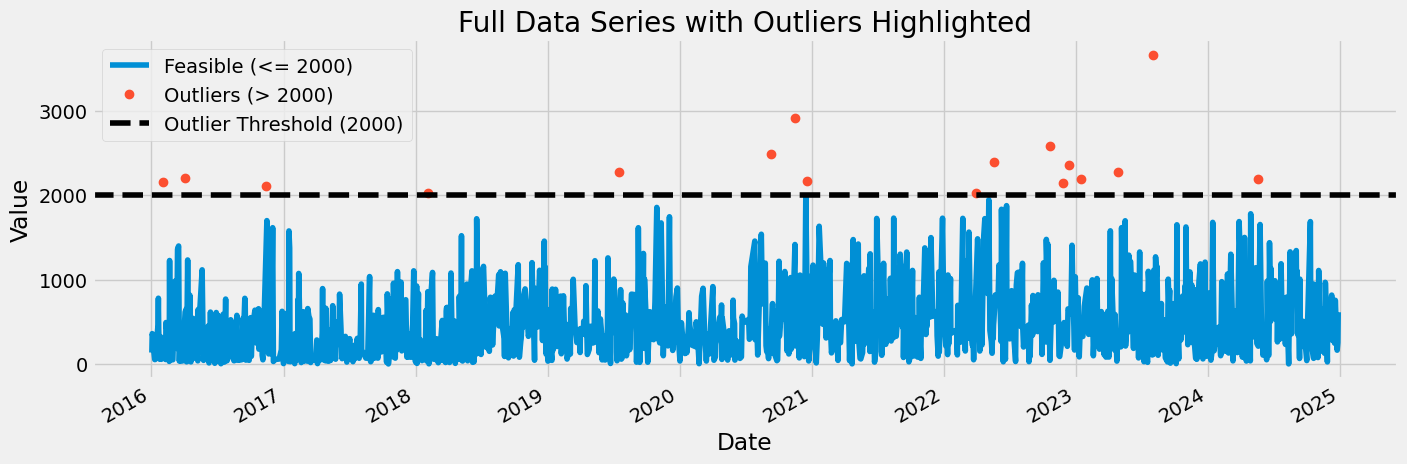

In [ ]:
# Plot the whole series in blue and outliers in orange
plt.figure(figsize=(15, 5))

# Plot the feasible values (less than or equal to 2000) in blue
df.loc[df['TargetXGB_scale'] <= 2000, 'TargetXGB_scale'].plot(ax=plt.gca(), label='Feasible (<= 2000)')

# Plot the outliers (greater than 2000) in orange
df.loc[df['TargetXGB_scale'] > 2000, 'TargetXGB_scale'].plot(ax=plt.gca(), label='Outliers (> 2000)', linestyle='None', marker='o') # Use markers for outliers

# Add a horizontal dashed black line at the threshold of 2000
plt.axhline(2000, color='black', linestyle='--', label='Outlier Threshold (2000)')

plt.title('Full Data Series with Outliers Highlighted')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

Assuming I will cut-off outliers.

In [ ]:
# Create a new DataFrame excluding outliers
df_cut = df.loc[df['TargetXGB_scale'] <= 2000].copy()

print("Shape after cutting outliers:", df_cut.shape)
print("\nMissing values per column after cutting outliers:\n", df_cut.isna().sum())
print("\nDate range after cutting outliers:", df_cut.index.min(), "to", df_cut.index.max())
print("\nSummary statistics after cutting outliers:\n", df_cut.describe())

Shape after cutting outliers: (1267, 12)

Missing values per column after cutting outliers:
 TargetXGB_scale           0
fueling_event             0
lag_1_day                 1
lag_2_days                2
lag_3_days                3
lag_1_week                7
lag_1_month              29
rolling_mean_1_week       6
rolling_mean_1_month     28
rolling_mean_3_month     87
rolling_mean_6_month    176
rolling_mean_1_year     360
dtype: int64

Date range after cutting outliers: 2016-01-03 00:00:00 to 2024-12-26 00:00:00

Summary statistics after cutting outliers:
        TargetXGB_scale  fueling_event    lag_1_day   lag_2_days   lag_3_days  \
count      1267.000000         1267.0  1266.000000  1265.000000  1264.000000   
mean        465.213694            1.0   489.539215   492.176735   490.829013   
std         394.700937            0.0   449.531288   451.400160   451.774690   
min           1.429083            1.0     1.429083     1.429083     1.429083   
25%         144.899288            

NameError: name 'df_cut' is not defined

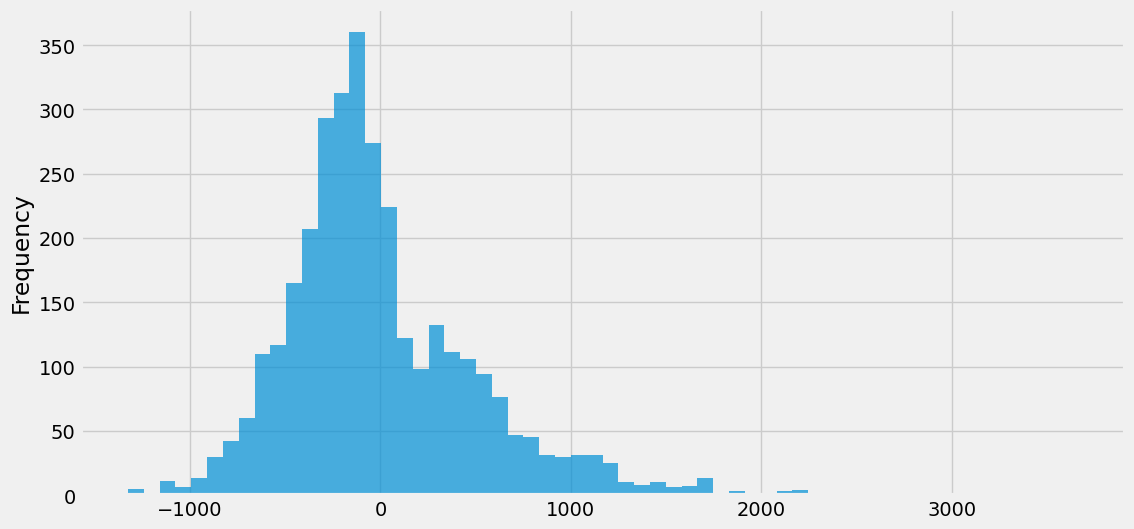

In [ ]:
plt.figure(figsize=(12, 6))
df['TargetXGB_scale'].plot(kind='hist', bins=60, alpha=0.7, label='Original Data')
df_cut['TargetXGB_scale'].plot(kind='hist', bins=60, alpha=0.7, label='Data without Outliers')
plt.title('Histogram of Full Consumption with and without Outliers')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()

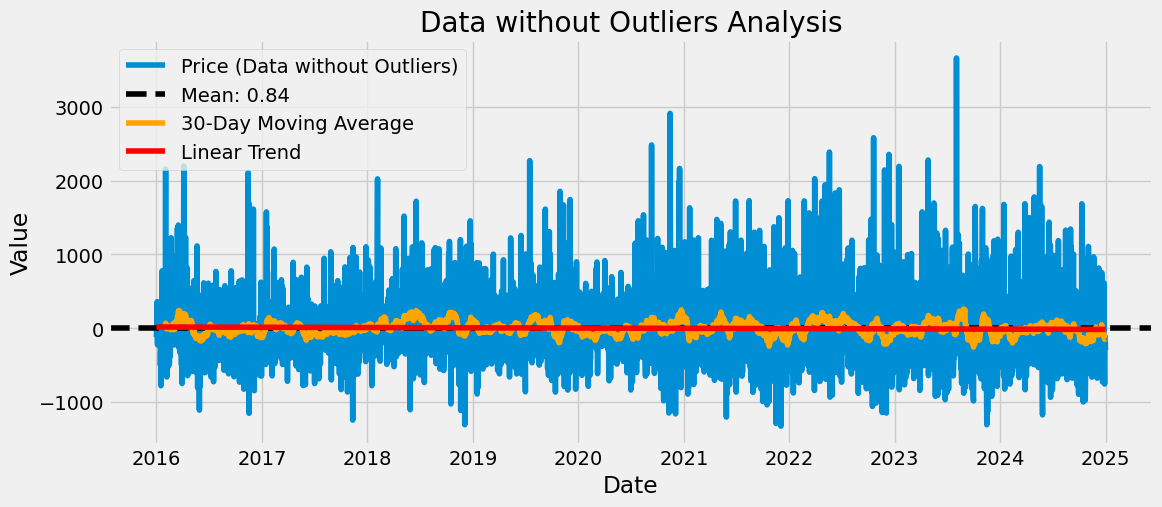

In [ ]:
# Create a new DataFrame excluding Outliers

# Use the new df_cut dataframe
data_to_plot = df.copy()


# Calculate the mean of the new dataset
mean_value_cut = data_to_plot.iloc[:, 0].mean()

# Calculate a 30-day rolling moving average for the new dataset
rolling_mean_cut = data_to_plot.iloc[:, 0].rolling(window=30).mean()

# Calculate the linear trend line for the new dataset
data_to_plot['date_ordinal'] = data_to_plot.index.map(pd.Timestamp.toordinal)
slope_cut, intercept_cut, r_value_cut, p_value_cut, std_err_cut = linregress(data_to_plot['date_ordinal'], data_to_plot.iloc[:, 0])
trend_line_cut = slope_cut * data_to_plot['date_ordinal'] + intercept_cut

# Drop the 'date_ordinal' column after calculating the trend line
data_to_plot = data_to_plot.drop(columns=['date_ordinal'])


plt.figure(figsize=(12,5))
plt.plot(data_to_plot.index, data_to_plot.iloc[:,0], label="Price (Data without Outliers)")
plt.axhline(mean_value_cut, color='black', linestyle='--', label=f'Mean: {mean_value_cut:.2f}')
plt.plot(data_to_plot.index, rolling_mean_cut, label='30-Day Moving Average', color='orange')
plt.plot(data_to_plot.index, trend_line_cut, label='Linear Trend', color='red', linestyle='-')

plt.title("Data without Outliers Analysis")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.show()

#3) Time Series Cross Validation

*The behavior of Cross-Validation will depend on the characteristics of the dataset, especially its length.*

Using TimeSeriesSplit with n_splits=8 and test_size=365 days:

Fold 1:
  Train: 2016-01-01 → 2017-01-02 (368 days)
  Test:  2017-01-03 → 2018-01-02 (365 days)

Fold 2:
  Train: 2016-01-01 → 2018-01-02 (733 days)
  Test:  2018-01-03 → 2019-01-02 (365 days)

Fold 3:
  Train: 2016-01-01 → 2019-01-02 (1098 days)
  Test:  2019-01-03 → 2020-01-02 (365 days)

Fold 4:
  Train: 2016-01-01 → 2020-01-02 (1463 days)
  Test:  2020-01-03 → 2021-01-01 (365 days)

Fold 5:
  Train: 2016-01-01 → 2021-01-01 (1828 days)
  Test:  2021-01-02 → 2022-01-01 (365 days)

Fold 6:
  Train: 2016-01-01 → 2022-01-01 (2193 days)
  Test:  2022-01-02 → 2023-01-01 (365 days)

Fold 7:
  Train: 2016-01-01 → 2023-01-01 (2558 days)
  Test:  2023-01-02 → 2024-01-01 (365 days)

Fold 8:
  Train: 2016-01-01 → 2024-01-01 (2923 days)
  Test:  2024-01-02 → 2024-12-31 (365 days)


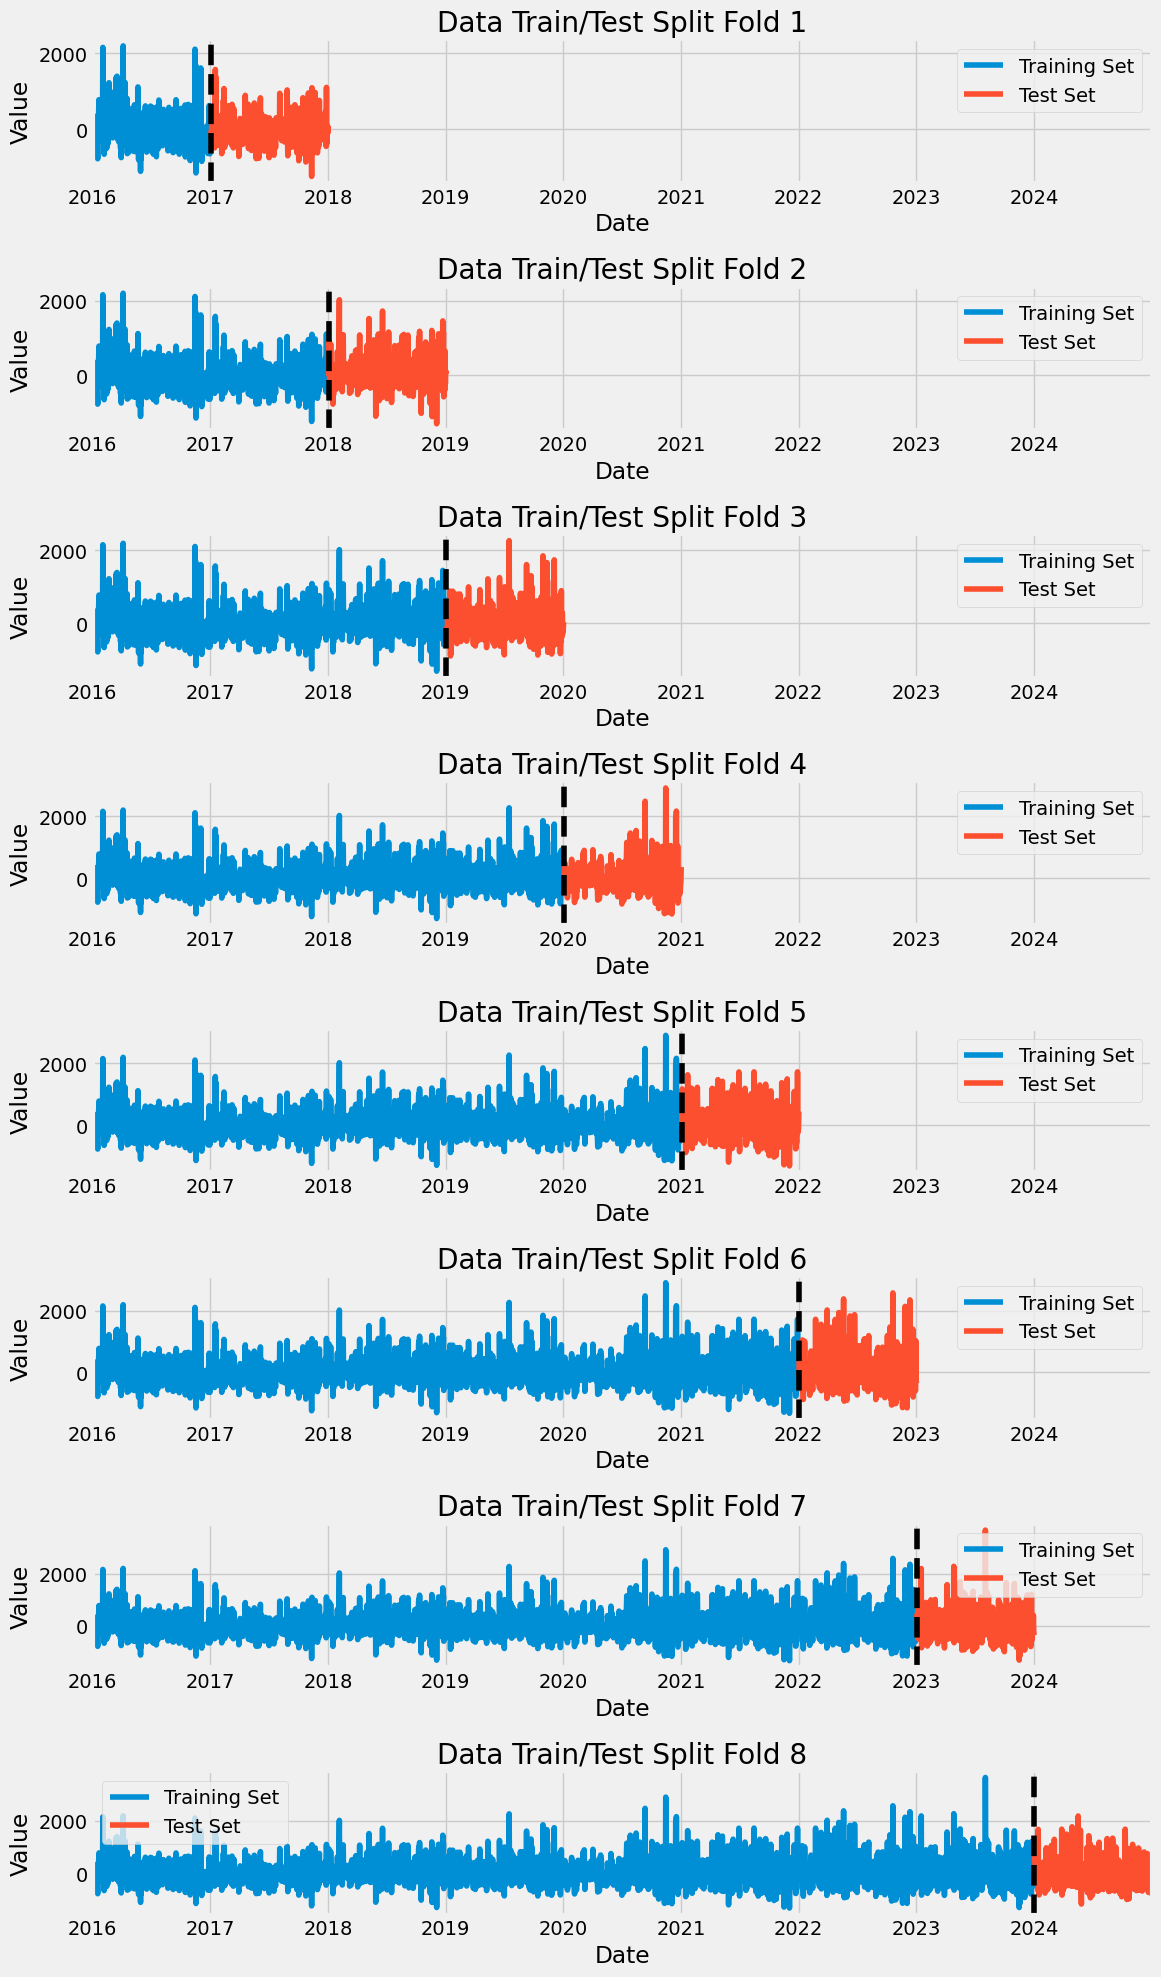

In [ ]:
#This code is just to understand the length of my later train/test split fold
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt

# Use df.copy if no outlier
data_for_split =  df.copy() #df_cut.copy()

# Calculate approximate test_size
tss = TimeSeriesSplit(n_splits=8, test_size=365) # Changed n_splits from 7 to 3

print(f"Using TimeSeriesSplit with n_splits={tss.n_splits} and test_size={tss.test_size} days:")

fig, axs = plt.subplots(tss.n_splits, 1, figsize=(12, 20), sharex=False) # Create subplots

fold_num = 0
# Get the date range of the last fold to set consistent x-axis limits
# Check if tss.split yields any folds before accessing elements
split_indices = list(tss.split(data_for_split))
if len(split_indices) > 0:
    last_train_index, last_test_index = split_indices[-1]
    last_fold_start = data_for_split.iloc[last_train_index[0]].name
    last_fold_end = data_for_split.iloc[last_test_index[-1]].name
else:
    print("No splits generated by TimeSeriesSplit. Adjust n_splits or test_size.")
    last_fold_start = data_for_split.index.min()
    last_fold_end = data_for_split.index.max()


for train_index, test_index in tss.split(data_for_split):
    train_data = data_for_split.iloc[train_index]
    test_data = data_for_split.iloc[test_index]
    # put the target here ->  train_data['target']  ex: sarima_residual_in_sample; or b100_gulf.
    train_data['TargetXGB_scale'].plot(ax=axs[fold_num],
                                 label='Training Set',
                                 title=f'Data Train/Test Split Fold {fold_num + 1}') # Use fold_num + 1 for title
    test_data['TargetXGB_scale'].plot(ax=axs[fold_num],
                                label='Test Set')
    axs[fold_num].axvline(test_data.index.min(), color='black', ls='--')
    axs[fold_num].legend(['Training Set', 'Test Set'])
    axs[fold_num].set_xlabel("Date") # Add x-label
    axs[fold_num].set_ylabel("Value") # Add y-label

    # Set the x-axis limits for each subplot to match the last fold
    axs[fold_num].set_xlim([last_fold_start, last_fold_end])

    print(f"\nFold {fold_num + 1}:") # Use fold_num + 1 for print
    print(f"  Train: {train_data.index.min().strftime('%Y-%m-%d')} \u2192 {train_data.index.max().strftime('%Y-%m-%d')} ({len(train_data)} days)")
    print(f"  Test:  {test_data.index.min().strftime('%Y-%m-%d')} \u2192 {test_data.index.max().strftime('%Y-%m-%d')} ({len(test_data)} days)")

    fold_num += 1

plt.tight_layout() # Adjust layout
plt.show()


## 3.1) Forecasting Horizon
### IF the data WAS INDEED changed in the OUTLIERS phase, here is the time to add it to 'df'... so we dont need to change its name for the outlier df_cut in the whole code

In [ ]:
# Assign the data set without Outliers to df
df = df.copy()
df

,TargetXGB_scale
date,
2016-01-01,-120.983909
2016-01-02,-0.581430
2016-01-03,136.177546
2016-01-04,360.280017
2016-01-05,-224.930599
...,...
2024-12-27,-459.423805
2024-12-28,-755.159526
2024-12-29,-265.189634


*Now that I confirmed if I changed/manipulated the data, I can create features for the 'df'.*

## 3.2) Create Features

In [ ]:
def create_features(df):
    """
    Create time series features based on time series index.
    """
    df = df.copy()
    df['dayofmonth'] = df.index.day
    df['dayofweek'] = df.index.dayofweek
    df['month'] = df.index.month
    df['quarter'] = df.index.quarter
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    return df

df = create_features(df)

**Evaluate Features** = Visualize Feature / Target Relationship

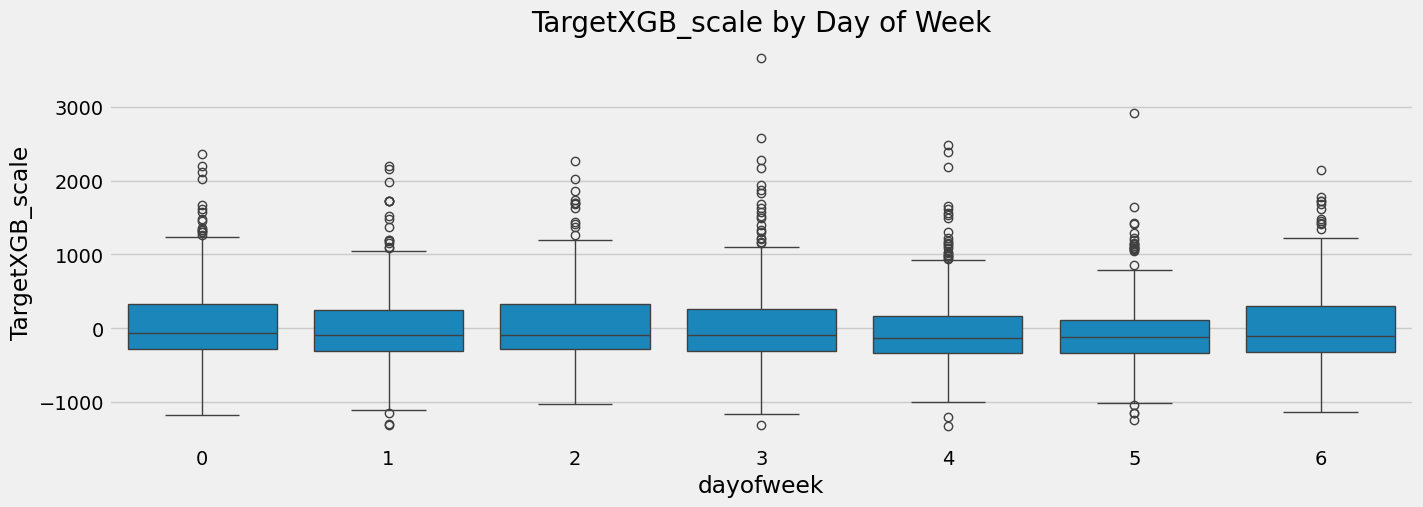

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))
sns.boxplot(data=df, x='dayofweek', y='TargetXGB_scale', ax=ax)
plt.title(file_name[:-4] + ' by Day of Week')
plt.show()

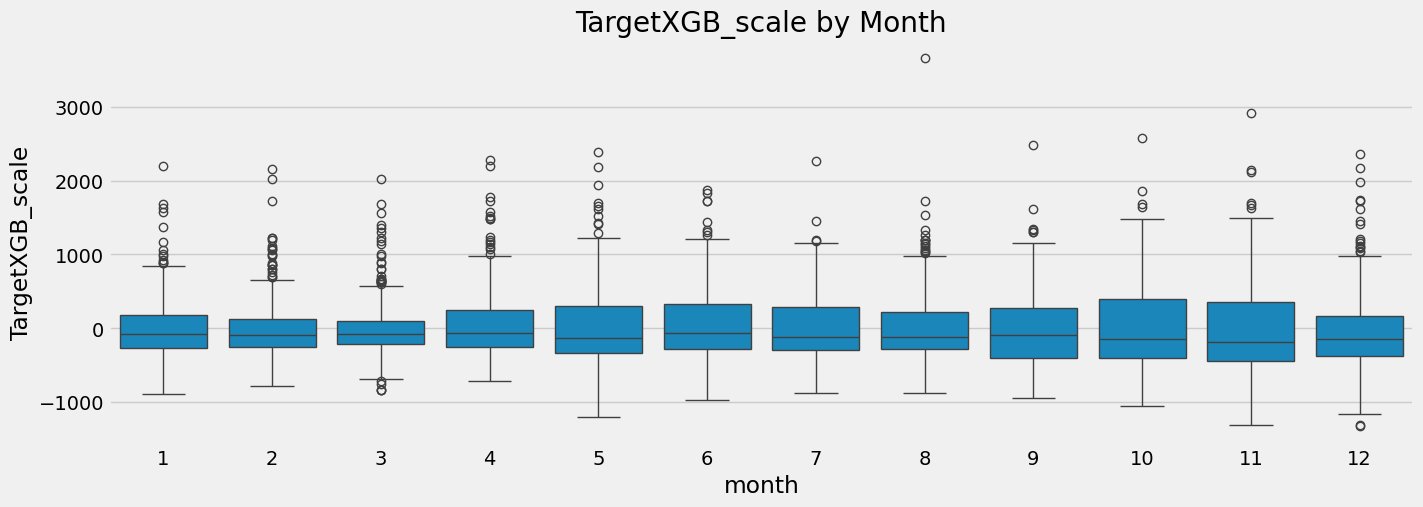

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))
sns.boxplot(data=df, x='month', y='TargetXGB_scale', ax=ax)
plt.title(file_name[:-4] + ' by Month')
plt.show()

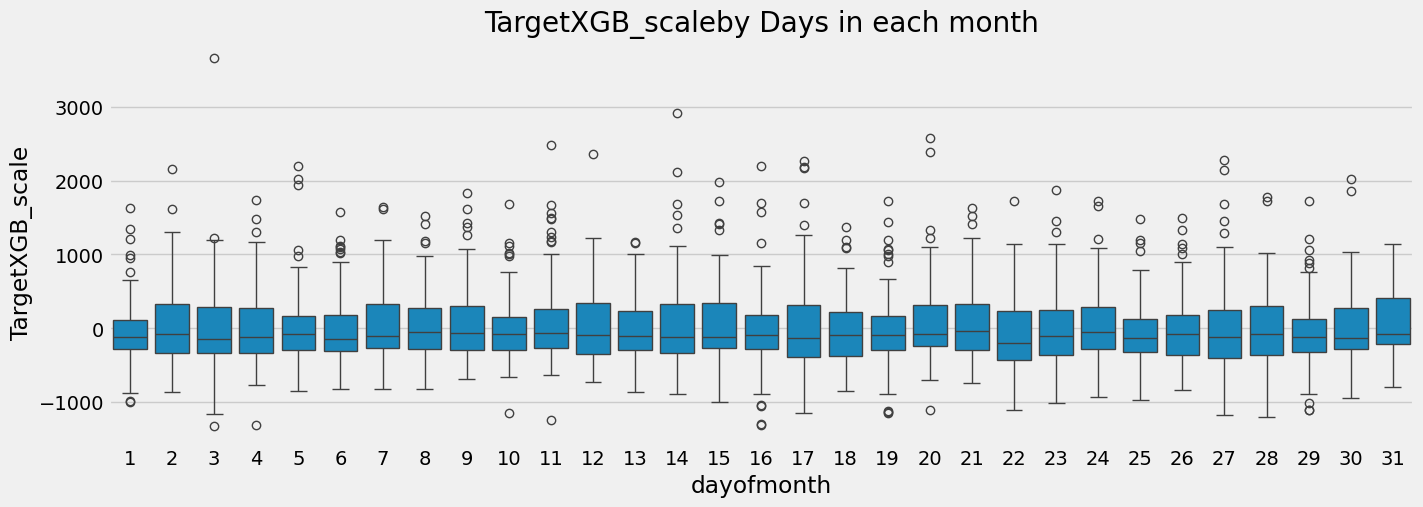

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))
sns.boxplot(data=df, x='dayofmonth', y='TargetXGB_scale', ax=ax)
plt.title(file_name[:-4] + 'by Days in each month')
plt.show()

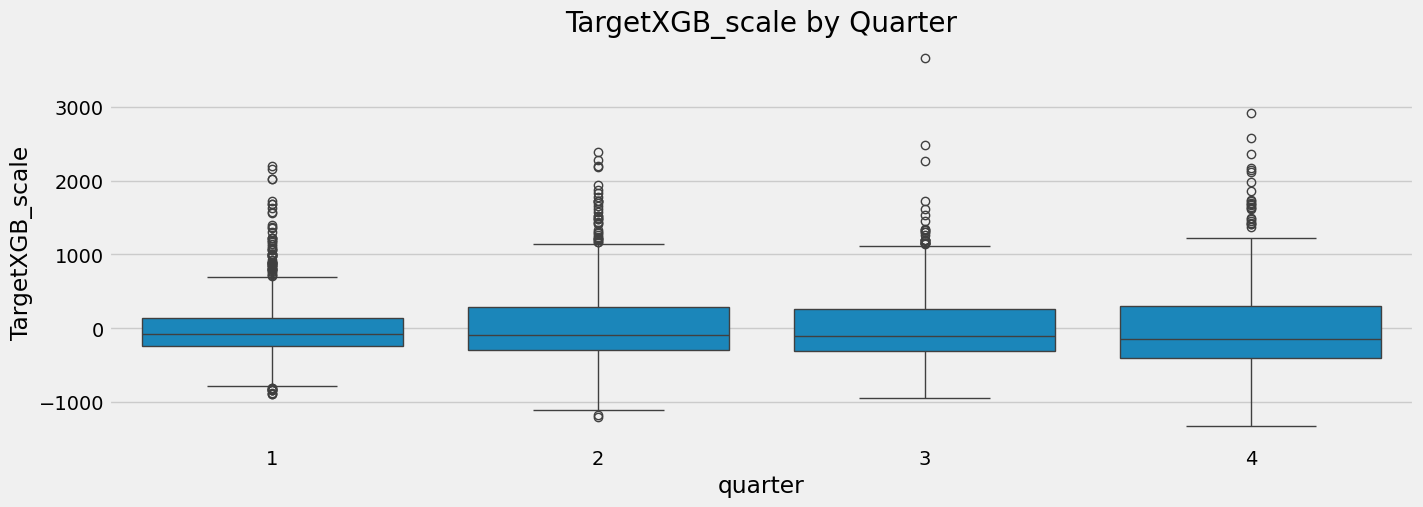

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))
sns.boxplot(data=df, x='quarter', y='TargetXGB_scale', ax=ax)
plt.title(file_name[:-4] + ' by Quarter')
plt.show()

## 3.3) Create Lag Features

In [ ]:
# I dont really need to use target_mapping because my shifts are goint to be based on fixed days, not early-mapped.
# target_map = df['b100_gulf'].to_dict()
# (df.index - pd.Timedelta('1')).map(target_map)

In [ ]:
def add_lags(df):
    """
    Create lag features and rolling mean features for the DataFrame.
    """
    # Sort the index first to ensure correct lag calculation
    df.sort_index(inplace=True)
    series_column = 'TargetXGB_scale' # Define the column name as a variable

    # Create Lag Features
    df['lag_1_day'] = df[series_column].shift(1)
    df['lag_2_days'] = df[series_column].shift(2)
    df['lag_3_days'] = df[series_column].shift(3)
    df['lag_1_week'] = df[series_column].shift(7)
    df['lag_1_month'] = df[series_column].shift(30) # Approximately one month

    # Create Rolling Mean Features
    df['rolling_mean_1_week'] = df[series_column].rolling(window=7).mean() # Approximately one week
    df['rolling_mean_1_month'] = df[series_column].rolling(window=30).mean() # Approximately one month
    df['rolling_mean_3_month'] = df[series_column].rolling(window=90).mean() # Approximately three months
    df['rolling_mean_6_month'] = df[series_column].rolling(window=180).mean() # Approximately six months
    df['rolling_mean_1_year'] = df[series_column].rolling(window=365).mean() # Approximately one year

    return df

# Apply the function to your DataFrame
df = add_lags(df.copy()) # Use a copy to avoid modifying the original df in place if you reuse the original later

Observe Lag Features

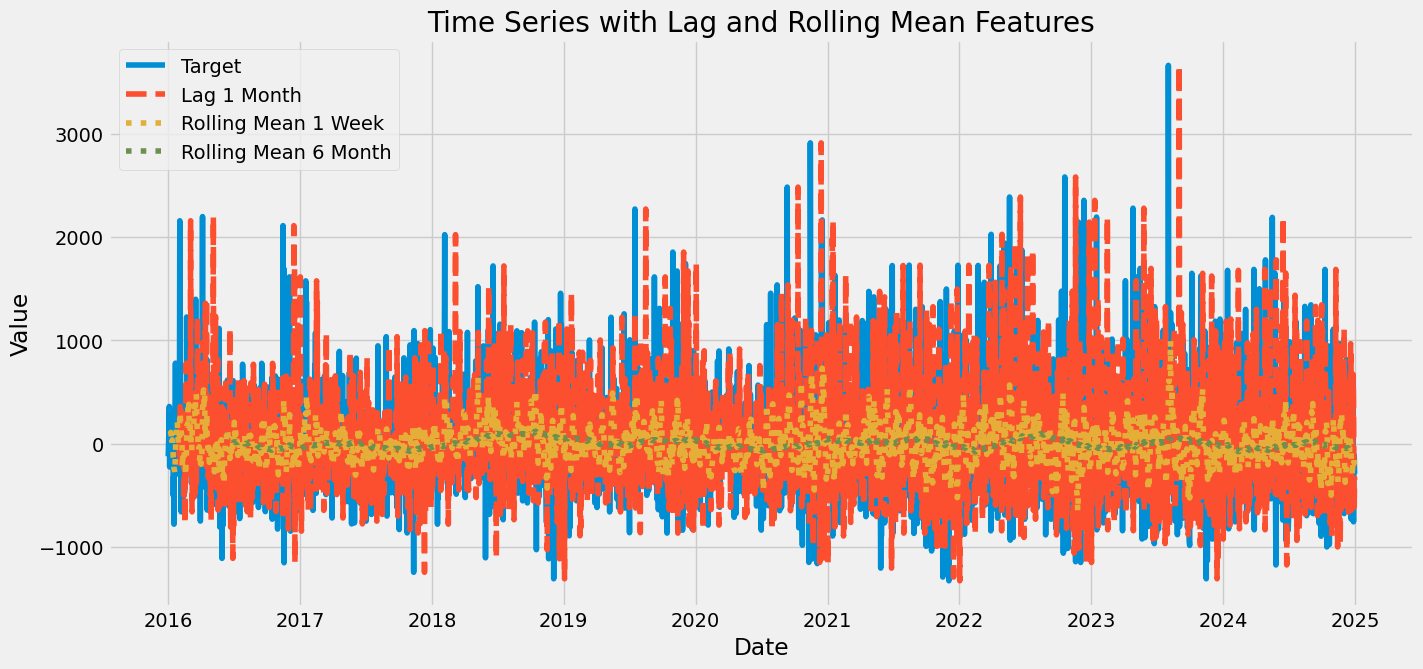

In [ ]:
plt.figure(figsize=(15, 7))
plt.plot(df.index, df['TargetXGB_scale'], label='Target') #b100_gulf
#plt.plot(df.index, df['lag_1_day'], label='Lag 1 Day', linestyle='--')
#plt.plot(df.index, df['lag_2_days'], label='Lag 2 Days', linestyle='--')
#plt.plot(df.index, df['lag_1_week'], label='Lag 1 Week', linestyle='--')
plt.plot(df.index, df['lag_1_month'], label='Lag 1 Month', linestyle='--')

plt.plot(df.index, df['rolling_mean_1_week'], label='Rolling Mean 1 Week', linestyle=':')
#plt.plot(df.index, df['rolling_mean_1_month'], label='Rolling Mean 1 Month', linestyle=':')
#plt.plot(df.index, df['rolling_mean_3_month'], label='Rolling Mean 3 Month', linestyle=':')
plt.plot(df.index, df['rolling_mean_6_month'], label='Rolling Mean 6 Month', linestyle=':')
#plt.plot(df.index, df['rolling_mean_1_year'], label='Rolling Mean 1 Year', linestyle=':')

plt.title('Time Series with Lag and Rolling Mean Features')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

## 3.4) Add Exogenous Features

In [ ]:
from google.colab import files
import pandas as pd
import io

exogenous_file_name = 'XGB_FULL_exogenous_input.csv' # Replace with your exogenous file name

# Initialize 'uploaded_exogenous' as an empty dictionary if it's not already defined
if 'uploaded_exogenous' not in locals():
  uploaded_exogenous = {}

if exogenous_file_name not in uploaded_exogenous:
  print(f"Please upload the file '{exogenous_file_name}'")
  uploaded_exogenous = files.upload()                 # will only ask once

# Use the correct column names based on user input
exogenous_df = pd.read_csv(io.BytesIO(uploaded_exogenous[exogenous_file_name]))

# Assuming 'index' is the date column in the exogenous file
exogenous_df['date'] = pd.to_datetime(exogenous_df['date'])
exogenous_df.set_index('date', inplace=True)

print("Exogenous Data Structure:")
display(exogenous_df.head())
display(exogenous_df.info())
display(exogenous_df.describe())

# Identify columns in exogenous_df that are not in df
cols_to_merge = exogenous_df.columns.difference(df.columns)

# Merge only the unique columns from exogenous_df into df
df = df.merge(exogenous_df[cols_to_merge], left_index=True, right_index=True, how='left')

print("\nUpdated DataFrame with Exogenous Features (unique columns only):")
display(df.tail())
display(df.info())

Please upload the file 'XGB_FULL_exogenous_input.csv'


Saving XGB_FULL_exogenous_input.csv to XGB_FULL_exogenous_input.csv
Exogenous Data Structure:


,usdcad_rate_w_future,diesel_transport_w_future,crud_oil_w_future,gasoline_w_future,eu_carbonpermit_w_future,heating_oil_w_future,soybean_oil_w_future,usdcad_rate_lag_1_day,usdcad_rate_lag_2_days,usdcad_rate_lag_3_days,...,b100_structured_res_lag_3_month,b100_structured_res_lag_6_month,b100_structured_res_lag_1_year,b100_structured_res_lag_2_year,b100_structured_res_rolling_mean_1_week,b100_structured_res_rolling_mean_1_month,b100_structured_res_rolling_mean_3_month,b100_structured_res_rolling_mean_6_month,b100_structured_res_rolling_mean_1_year,b100_structured_res_rolling_mean_2_year
date,,,,,,,,,,,,,,,,,,,,,
2015-07-16,1.2957,2.7660,50.91,189.67,7.65,166.62,31.46,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-07-17,1.2972,2.7675,50.89,192.86,7.73,166.41,31.78,1.2957,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-07-18,1.2972,2.7675,50.89,192.86,7.73,166.41,31.78,1.2972,1.2957,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-07-19,1.2972,2.7675,50.89,192.86,7.73,166.41,31.78,1.2972,1.2972,1.2957,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-07-20,1.2994,2.7646,50.15,193.03,7.97,165.84,31.68,1.2972,1.2972,1.2972,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5464 entries, 2015-07-16 to 2030-06-30
Columns: 292 entries, usdcad_rate_w_future to b100_structured_res_rolling_mean_2_year
dtypes: float64(292)
memory usage: 12.2 MB


None

,usdcad_rate_w_future,diesel_transport_w_future,crud_oil_w_future,gasoline_w_future,eu_carbonpermit_w_future,heating_oil_w_future,soybean_oil_w_future,usdcad_rate_lag_1_day,usdcad_rate_lag_2_days,usdcad_rate_lag_3_days,...,b100_structured_res_lag_3_month,b100_structured_res_lag_6_month,b100_structured_res_lag_1_year,b100_structured_res_lag_2_year,b100_structured_res_rolling_mean_1_week,b100_structured_res_rolling_mean_1_month,b100_structured_res_rolling_mean_3_month,b100_structured_res_rolling_mean_6_month,b100_structured_res_rolling_mean_1_year,b100_structured_res_rolling_mean_2_year
count,5464.000000,5464.000000,5464.000000,5464.000000,5464.000000,5464.000000,5464.000000,3675.000000,3675.000000,3675.000000,...,2920.000000,2920.000000,2920.000000,2920.000000,2926.000000,2949.000000,3009.000000,3099.000000,3284.000000,3649.000000
mean,1.349585,3.590516,66.816171,219.659242,56.297747,225.008225,48.777824,1.323450,1.323450,1.323450,...,-0.415206,-0.415206,-0.415206,-0.415206,-0.412350,-0.401131,-0.372822,-0.335619,-0.275546,-0.230863
std,0.055157,0.796986,15.955441,62.574796,34.164191,62.093765,15.138638,0.048101,0.048101,0.048101,...,1.490556,1.490556,1.490556,1.490556,1.484402,1.464442,1.412687,1.320899,1.106765,0.801234
min,1.203500,1.998200,10.010000,41.180000,3.930000,61.040000,24.990000,1.203500,1.203500,1.203500,...,-6.545864,-6.545864,-6.545864,-6.545864,-6.466288,-6.256388,-5.924026,-5.322913,-3.639963,-1.737139
25%,1.309500,2.986600,54.930000,166.517500,22.160000,186.060000,32.660000,1.288900,1.288900,1.288900,...,-0.415903,-0.415903,-0.415903,-0.415903,-0.415497,-0.415986,-0.404883,-0.400329,-0.402891,-0.387759
50%,1.354450,3.738644,70.460000,218.436741,69.560000,236.875000,53.305000,1.324300,1.324300,1.324300,...,-0.068059,-0.068059,-0.068059,-0.068059,-0.068594,-0.070542,-0.074308,-0.095081,-0.154320,-0.140485
75%,1.397501,4.185278,76.995860,262.226043,84.932334,258.459829,61.690946,1.355300,1.355300,1.355300,...,0.126019,0.126019,0.126019,0.126019,0.125478,0.136494,0.160540,0.162062,0.157915,0.021210
max,1.457900,5.807400,123.700000,427.620000,109.898050,513.540000,90.600000,1.457900,1.457900,1.457900,...,2.198395,2.198395,2.198395,2.198395,2.169247,2.102383,2.102383,2.102383,2.102383,2.102383



Updated DataFrame with Exogenous Features (unique columns only):


,TargetXGB_scale,dayofmonth,dayofweek,month,quarter,year,dayofyear,lag_1_day,lag_2_days,lag_3_days,...,usdcad_rate_res_rolling_mean_2_year,usdcad_rate_res_rolling_mean_3_month,usdcad_rate_res_rolling_mean_6_month,usdcad_rate_rolling_mean_1_month,usdcad_rate_rolling_mean_1_week,usdcad_rate_rolling_mean_1_year,usdcad_rate_rolling_mean_2_year,usdcad_rate_rolling_mean_3_month,usdcad_rate_rolling_mean_6_month,usdcad_rate_w_future
date,,,,,,,,,,,,,,,,,,,,,
2024-12-27,-459.423805,27,4,12,4,2024,362,613.080000,254.150024,-582.802209,...,0.009323,-0.005357,-0.005648,1.421830,1.437786,1.369060,1.359386,1.396971,1.380759,1.4412
2024-12-28,-755.159526,28,5,12,4,2024,363,-459.423805,613.080000,254.150024,...,0.009326,-0.004308,-0.005465,1.423157,1.438543,1.369380,1.359505,1.397967,1.381134,1.4412
2024-12-29,-265.189634,29,6,12,4,2024,364,-755.159526,-459.423805,613.080000,...,0.009333,-0.003257,-0.005251,1.424510,1.439300,1.369701,1.359622,1.398952,1.381542,1.4412
2024-12-30,-112.940215,30,0,12,4,2024,365,-265.189634,-755.159526,-459.423805,...,0.009325,-0.002223,-0.005045,1.425673,1.439071,1.370005,1.359732,1.399913,1.381939,1.4355
2024-12-31,-290.885828,31,1,12,4,2024,366,-112.940215,-265.189634,-755.159526,...,0.009328,-0.001157,-0.004809,1.426933,1.439457,1.370319,1.359846,1.400893,1.382367,1.4384


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3288 entries, 2016-01-01 to 2024-12-31
Freq: D
Columns: 309 entries, TargetXGB_scale to usdcad_rate_w_future
dtypes: float64(303), int32(6)
memory usage: 7.8 MB


None

Now, I will merge the exogenous data with the main dataframe.

In [ ]:
# Merge the dataframes. Using a left join to keep all dates from the main df.
# If you want to keep only dates present in both dataframes, use an inner join.
# The merge operation might create duplicate columns if the same column names exist in both dataframes.
# We will drop the duplicate columns with suffixes after merging.
df = df.merge(exogenous_df, left_index=True, right_index=True, how='left')

# Identify and drop duplicate columns that resulted from the merge
# We assume the original columns in df are the ones to keep, and the ones with suffixes are duplicates.
cols_to_drop = [col for col in df.columns if '_y' in col]
df = df.drop(columns=cols_to_drop)

# Rename columns that might have _x suffix to their original names
df.columns = df.columns.str.replace('_x$', '', regex=True)


print("Updated DataFrame with Exogenous Features (Duplicates Removed):")
display(df.tail())
display(df.info())

Updated DataFrame with Exogenous Features (Duplicates Removed):


,TargetXGB_scale,dayofmonth,dayofweek,month,quarter,year,dayofyear,lag_1_day,lag_2_days,lag_3_days,...,usdcad_rate_res_lag_6_month,usdcad_rate_res_rolling_mean_1_month,usdcad_rate_res_rolling_mean_1_week,usdcad_rate_res_rolling_mean_3_month,usdcad_rate_res_rolling_mean_6_month,usdcad_rate_rolling_mean_1_month,usdcad_rate_rolling_mean_1_week,usdcad_rate_rolling_mean_3_month,usdcad_rate_rolling_mean_6_month,usdcad_rate_w_future
date,,,,,,,,,,,,,,,,,,,,,
2024-12-27,-459.423805,27,4,12,4,2024,362,613.080000,254.150024,-582.802209,...,0.010315,0.023440,0.045744,-0.005357,-0.005648,1.421830,1.437786,1.396971,1.380759,1.4412
2024-12-28,-755.159526,28,5,12,4,2024,363,-459.423805,613.080000,254.150024,...,0.017034,0.025270,0.046782,-0.004308,-0.005465,1.423157,1.438543,1.397967,1.381134,1.4412
2024-12-29,-265.189634,29,6,12,4,2024,364,-755.159526,-459.423805,613.080000,...,0.012965,0.027205,0.047926,-0.003257,-0.005251,1.424510,1.439300,1.398952,1.381542,1.4412
2024-12-30,-112.940215,30,0,12,4,2024,365,-265.189634,-755.159526,-459.423805,...,0.007819,0.028931,0.048047,-0.002223,-0.005045,1.425673,1.439071,1.399913,1.381939,1.4355
2024-12-31,-290.885828,31,1,12,4,2024,366,-112.940215,-265.189634,-755.159526,...,0.006878,0.030836,0.048742,-0.001157,-0.004809,1.426933,1.439457,1.400893,1.382367,1.4384


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3288 entries, 2016-01-01 to 2024-12-31
Freq: D
Columns: 236 entries, TargetXGB_scale to usdcad_rate_w_future
dtypes: float64(230), int32(6)
memory usage: 6.0 MB


None

##Here is a list of all columns in the updated dataframe. You can use this to select the features for your model.

In [ ]:
# Display all column names in the requested format for copy-pasting
print("Column names in the updated dataframe (for copy-pasting into FEATURES list):")
for col in df.columns:
    print(f"'{col}',")

Column names in the updated dataframe (for copy-pasting into FEATURES list):
'TargetXGB_scale',
'dayofmonth',
'dayofweek',
'month',
'quarter',
'year',
'dayofyear',
'lag_1_day',
'lag_2_days',
'lag_3_days',
'lag_1_week',
'lag_1_month',
'rolling_mean_1_week',
'rolling_mean_1_month',
'rolling_mean_3_month',
'rolling_mean_6_month',
'b100_rolling_w_future',
'b100_structured_lag_1_day',
'b100_structured_lag_1_month',
'b100_structured_lag_1_week',
'b100_structured_lag_2_days',
'b100_structured_lag_3_days',
'b100_structured_lag_3_month',
'b100_structured_lag_6_month',
'b100_structured_res',
'b100_structured_res_lag_1_day',
'b100_structured_res_lag_1_month',
'b100_structured_res_lag_1_week',
'b100_structured_res_lag_2_days',
'b100_structured_res_lag_3_days',
'b100_structured_res_lag_3_month',
'b100_structured_res_lag_6_month',
'b100_structured_res_rolling_mean_1_month',
'b100_structured_res_rolling_mean_1_week',
'b100_structured_res_rolling_mean_3_month',
'b100_structured_res_rolling_mean_6_mont

##3.5 classification Feature creation


In [ ]:
# --- 3.5.1 Prepare Classification Copy ---
df_clf = df.copy()
df_clf['error_positive'] = (df_clf['TargetXGB_scale'] > 0).astype(int)
# Removed redundant create_features and add_lags calls as df_clf is a copy of df which already has these.

clf_features = [
    'dayofweek', 'month', 'year',
    'lag_1_day', 'lag_2_days', 'lag_3_days', 'lag_1_week', 'lag_1_month',
    'rolling_mean_1_week', 'rolling_mean_1_month', 'rolling_mean_3_month', 'rolling_mean_6_month',
    # 'rolling_mean_1_year', # Exclude this if not consistently generated for classification
]

from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit

X_clf = df_clf[clf_features]
y_clf = df_clf['error_positive']

clf_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
                           )
# Use last fold training logic
tss = TimeSeriesSplit(n_splits=5)
for train_idx, test_idx in tss.split(df_clf):
    X_train_clf, y_train_clf = X_clf.iloc[train_idx], y_clf.iloc[train_idx]

clf_model.fit(X_train_clf, y_train_clf)

# --- 3.5.2 Generate probability and attach to main df ---
df['prob_error_positive'] = clf_model.predict_proba(X_clf)[:, 1]

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [20:21:05] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.89      0.81      2004
           1       0.75      0.54      0.63      1284

    accuracy                           0.75      3288
   macro avg       0.75      0.71      0.72      3288
weighted avg       0.75      0.75      0.74      3288



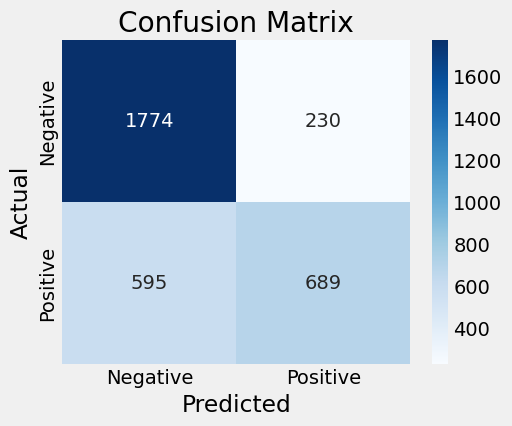

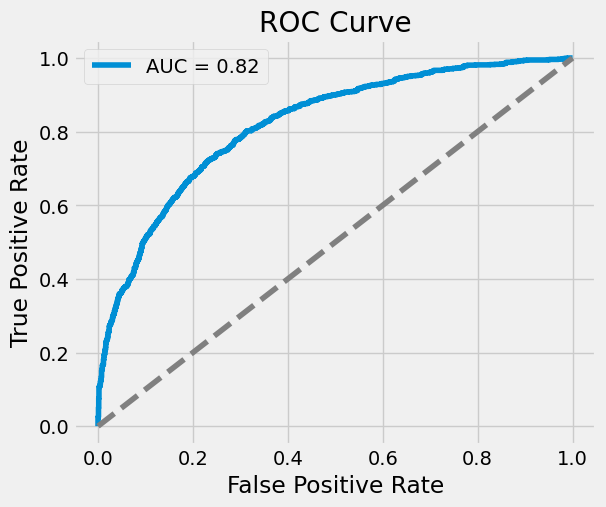



True Positive (TP):  689  | 21.0%
False Positive (FP): 230  | 7.0%
True Negative (TN):  1774  | 54.0%
False Negative (FN): 595  | 18.1%

✔️ Correct Predictions:   2463  | 74.9%
❌ Incorrect Predictions: 825  | 25.1%


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Predict labels and probabilities
y_pred = clf_model.predict(X_clf)
y_proba = clf_model.predict_proba(X_clf)[:, 1]

# --- Classification Report ---
print("Classification Report:\n")
print(classification_report(y_clf, y_pred))

# --- Confusion Matrix ---
cm = confusion_matrix(y_clf, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# --- ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_clf, y_proba)
roc_auc = roc_auc_score(y_clf, y_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

# Get counts
tn, fp, fn, tp = confusion_matrix(y_clf, y_pred).ravel()
total = tn + fp + fn + tp

# Print detailed breakdown
print("\n")
print(f"True Positive (TP):  {tp}  | {tp / total:.1%}")
print(f"False Positive (FP): {fp}  | {fp / total:.1%}")
print(f"True Negative (TN):  {tn}  | {tn / total:.1%}")
print(f"False Negative (FN): {fn}  | {fn / total:.1%}")
print()
print(f"✔️ Correct Predictions:   {tp + tn}  | {(tp + tn) / total:.1%}")
print(f"❌ Incorrect Predictions: {fp + fn}  | {(fp + fn) / total:.1%}")

### 3.5.3 Auto-tune XGBoost Classifier Parameters

This section performs hyperparameter tuning for the `XGBClassifier` using `RandomizedSearchCV` with `TimeSeriesSplit` for cross-validation. This helps find optimal parameters to improve the model's performance.

In [ ]:
# --- Hyperparameter Tuning for XGBClassifier with RandomizedSearchCV --- #

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Define the parameter distribution for RandomizedSearchCV
param_distributions_clf = {
    'n_estimators': randint(50, 500), # Number of boosting rounds
    'learning_rate': uniform(0.01, 0.2), # Step size shrinkage to prevent overfitting
    'max_depth': randint(3, 10), # Maximum depth of a tree
    'subsample': uniform(0.6, 0.4), # Subsample ratio of the training instance
    'colsample_bytree': uniform(0.6, 0.4), # Subsample ratio of columns when constructing each tree
    'gamma': uniform(0, 0.5), # Minimum loss reduction required to make a further partition on a leaf node
    'min_child_weight': randint(1, 10), # Minimum sum of instance weight (hessian) needed in a child
}

# Initialize XGBClassifier with default parameters for tuning
clf_tune = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

# Use TimeSeriesSplit for consistent cross-validation
tss_clf = TimeSeriesSplit(n_splits=2) # Can adjust n_splits if needed

# Initialize RandomizedSearchCV
random_search_clf = RandomizedSearchCV(
    estimator=clf_tune,
    param_distributions=param_distributions_clf,
    n_iter=50, # Number of parameter settings that are sampled. Adjust as needed for thoroughness vs. speed.
    scoring='roc_auc', # Evaluate based on AUC score
    n_jobs=-1, # Use all available cores
    cv=tss_clf,
    verbose=1,
    random_state=42
)

print("Starting RandomizedSearchCV for XGBoost Classifier...")

# Fit RandomizedSearchCV to the classification features and target
random_search_clf.fit(X_clf, y_clf)

print("RandomizedSearchCV complete.")

# Display the best parameters and best score found
print("\nBest parameters found for XGBoost Classifier:")
display(random_search_clf.best_params_)

print("Best ROC AUC score:")
display(random_search_clf.best_score_)


Starting RandomizedSearchCV for XGBoost Classifier...
Fitting 2 folds for each of 50 candidates, totalling 100 fits


KeyboardInterrupt: 

# 4) Training Using Cross Validation




## 4.1) This is the real Train/Test set using XGB with the features


In [ ]:
import numpy as np # Ensure numpy is imported

#Remember to use the same TRAIN/TEST split from 3)
tss = TimeSeriesSplit(n_splits=8, test_size=365)#short 5 to 90// long 7 to 365
df = df.sort_index()

# Calculate MAPE, handling potential division by zero if actual values are zero
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_indices = y_true != 0
    if not np.any(non_zero_indices):
        return np.nan # Avoid division by zero if all y_true are zero
    return np.mean(np.abs((y_true[non_zero_indices] - y_pred[non_zero_indices]) / y_true[non_zero_indices])) * 100

fold = 0
preds = []
scores = [] # RMSE
maes = []
mapes = []
r2s = []

for train_index, val_index in tss.split(df):
    train = df.iloc[train_index]
    test = df.iloc[val_index]

    train = create_features(train)
    test = create_features(test)



    FEATURES = [

    # Time features
    'dayofmonth',
    'dayofweek',
    'month',
    'quarter',
    'year',
    'dayofyear',

    # Exogenous market signals (minimal impact, but included)
    'diesel_transport_w_future',
    'gasoline_w_future',
    'heating_oil_w_future',
    'soybean_oil_w_future',
    'usdcad_rate_w_future',

    # Cross-dependency + baseline signals
    'scale_rolling_w_future',
    'passage_rolling_w_future',

    # Error autocorrelation (primary predictive power)
    'passage_res',
    'passage_res_lag_1_day',
    'passage_res_lag_1_week',
    'passage_res_lag_1_month',
    'passage_res_rolling_mean_1_month',
    'passage_res_rolling_mean_3_month',
    'passage_res_rolling_mean_6_month',

    'scale_res',
    'scale_res_lag_1_day',
    'scale_res_lag_1_week',
    'scale_res_lag_1_month',
    'scale_res_rolling_mean_1_month',
    'scale_res_rolling_mean_3_month',
    'scale_res_rolling_mean_6_month',

    # Error pattern classifier
    'prob_error_positive'

    ]

    TARGET =  'TargetXGB_scale'

    X_train= train[FEATURES]
    y_train = train[TARGET]

    X_test = test[FEATURES]
    y_test = test[TARGET]

    reg = xgb.XGBRegressor(
        #base_score=0.5,               # Removed (default and unused)
        booster='gbtree',               # Kept (it's default, so optional)
        n_estimators=1000,              # was 600 \u2192 more room, early stopping will cut early if needed
        early_stopping_rounds=100,      # was 50 \u2192 better buffer to stop safely
        objective='reg:squarederror',   # was 'reg:linear' \u2192 updated (linear is deprecated)
        max_depth=5,                    # was 3 \u2192 slightly more model capacity
        learning_rate=0.05,             # was 0.01 \u2192 converge faster with same accuracy
        #subsample=0.692758444537885,                  # NEW \u2192 regularization (helps generalization)
        #colsample_bytree=0.714708079716337,           # NEW \u2192 regularization (column-level)
        #gamma=0.30915086159001515,                      # NEW \u2192 avoid unnecessary splits
        #min_child_weight=5.25,             # NEW \u2192 limit small data-driven splits
        #verbosity=2                     # Optional: reduce log spam if needed
    )#0.0547534081037697

    # Convert X_train and X_test to numpy arrays before fitting
    reg.fit(X_train.values, y_train.values,
            eval_set=[(X_train.values, y_train.values), (X_test.values, y_test.values)],
            verbose=100)

    y_pred = reg.predict(X_test.values)
    preds.append(y_pred)

    # Calculate and store all required metrics
    score = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    scores.append(score)
    maes.append(mae)
    mapes.append(mape)
    r2s.append(r2)

    print(f'  RMSE: {np.mean(scores):0.4f}')
    print(f'  MAE:  {np.mean(maes):0.4f}')
    print(f'  MAPE: {np.nanmean(mapes):0.2f}%') # Use nanmean to handle potential NaN from MAPE
    print(f'  R^2:  {np.mean(r2s):0.4f}')

[0]	validation_0-rmse:436.59003	validation_1-rmse:366.64770
[100]	validation_0-rmse:155.34760	validation_1-rmse:349.51986
[122]	validation_0-rmse:142.75160	validation_1-rmse:352.09247
  RMSE: 327.5263
  MAE:  242.4955
  MAPE: 205.26%
  R^2:  0.2303
[0]	validation_0-rmse:401.08814	validation_1-rmse:447.30067
[100]	validation_0-rmse:171.35697	validation_1-rmse:277.15481
[191]	validation_0-rmse:134.76620	validation_1-rmse:280.83532
  RMSE: 301.8622
  MAE:  220.2699
  MAPE: 212.28%
  R^2:  0.4294
[0]	validation_0-rmse:415.06981	validation_1-rmse:444.86476
[100]	validation_0-rmse:173.56440	validation_1-rmse:220.16985
[200]	validation_0-rmse:136.76899	validation_1-rmse:224.65720
  RMSE: 274.6314
  MAE:  205.1904
  MAPE: 193.86%
  R^2:  0.5430
[0]	validation_0-rmse:421.77909	validation_1-rmse:484.12490
[100]	validation_0-rmse:169.15835	validation_1-rmse:272.15868
[152]	validation_0-rmse:150.02668	validation_1-rmse:287.84674
  RMSE: 272.4308
  MAE:  203.3984
  MAPE: 179.32%
  R^2:  0.5864
[0]	

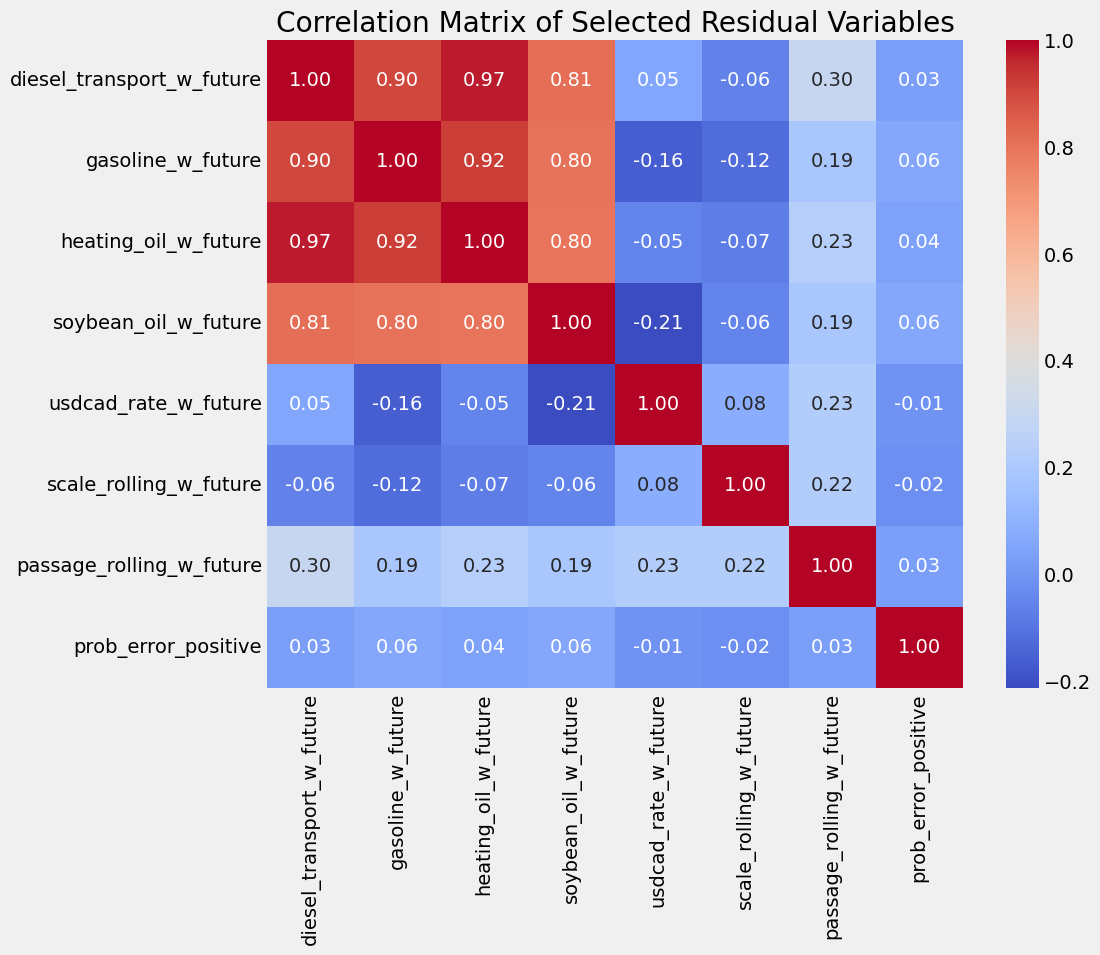

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# List of variables to test correlation for
correlation_vars = [
 'diesel_transport_w_future',
    'gasoline_w_future',
    'heating_oil_w_future',
    'soybean_oil_w_future',
    'usdcad_rate_w_future',
     'scale_rolling_w_future',
    'passage_rolling_w_future',
  'prob_error_positive',
]

# Select the variables from the DataFrame
correlation_df = df[correlation_vars].copy()

# Calculate the correlation matrix
correlation_matrix = correlation_df.corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Selected Residual Variables')
plt.show()


In [ ]:
print(f'\nAverage Scores across folds:')
print(f'  RMSE: {np.mean(scores):0.4f}')
print(f'  MAE:  {np.mean(maes):0.4f}')
print(f'  MAPE: {np.nanmean(mapes):0.2f}%') # Use nanmean to handle potential NaN from MAPE
print(f'  R^2:  {np.mean(r2s):0.4f}')


Average Scores across folds:
  RMSE: 254.3446
  MAE:  193.4026
  MAPE: 173.63%
  R^2:  0.7109


In [ ]:
print(f'Scores across folds {np.mean(scores):0.4f}')
print('Fold scores:')
for i, score in enumerate(scores):
    print(f'  Fold {i+1}: {score:0.4f}')

Scores across folds 254.3446
Fold scores:
  Fold 1: 327.5263
  Fold 2: 276.1982
  Fold 3: 220.1698
  Fold 4: 265.8290
  Fold 5: 254.2372
  Fold 6: 239.3587
  Fold 7: 241.9038
  Fold 8: 209.5338


###CODE TO AUTO-TUNE HYPERPARAMETERS

In [ ]:
# --- Hyperparameter Tuning with RandomizedSearchCV (New Cell) ---

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Use the same TimeSeriesSplit as before
tss = TimeSeriesSplit(n_splits=8, test_size=365)

# Ensure the dataframe is sorted by index (date) for time series splitting
df = df.sort_index()

# Define the parameter distribution for RandomizedSearchCV
param_distributions = {
    'n_estimators': randint(100, 1000),
    'learning_rate': uniform(0.01, 0.1),
    'max_depth': randint(3, 10),
    'subsample': uniform(0.5, 0.5),
    'colsample_bytree': uniform(0.5, 0.5),
    'gamma': uniform(0, 0.5),
    'min_child_weight': randint(1, 10),
}

# Initialize lists to store best parameters and scores for each fold
best_params_per_fold = []
best_scores_per_fold = []
tuned_preds = [] # Store predictions from the tuned model for plotting later
tuned_scores = [] # Store RMSE scores from the tuned model

print("Starting Hyperparameter Tuning with RandomizedSearchCV across Time Series Splits...")

fold = 0
for train_index, val_index in tss.split(df):
    train = df.iloc[train_index]
    test = df.iloc[val_index]

    # Create features for train and test sets within the loop
    train = create_features(train)
    test = create_features(test)

    # Define features and target - Make sure these match your data
    FEATURES = [
'full_consumption_passage_residual',
'rolling_mean_1_week',
'full_consumption_passage_res_rolling_mean_1_month',
'full_consumption_passage_res_rolling_mean_1_week',
'full_consumption_passage_res_lag_6_month',
'full_consumption_passage_res_rolling_mean_3_month',
'lag_1_day',
'soybean_oil_res_lag_6_month',
'lag_2_days',
'dayofyear',
'lag_1_week',
'full_consumption_passage_res_lag_3_days',
'lag_3_days',
'full_consumption_passage_res_lag_2_days',
'dayofweek',
'month',
'diesel_transport_w_future',
'eu_carbonpermit_w_future',
'year',
'fuel_consumption_res_rolling_mean_1_week',
'heating_oil_w_future',
'heating_oil_res_lag_6_month',
'soybean_oil_res_rolling_mean_6_month',
'soybean_oil_res_lag_3_month',
'full_consumption_passage_res_lag_1_day',
'full_consumption_passage_rolling_w_future',
'rolling_mean_3_month',
'rolling_mean_6_month',
'full_consumption_passage_res_lag_1_week',
'usdcad_rate_w_future',
'eu_carbonpermit_res_rolling_mean_3_month',
'rolling_mean_1_month',
'lag_1_month',
'full_consumption_passage_res_lag_3_month',
'dayofmonth',
'full_consumption_passage_res_rolling_mean_6_month',
'soybean_oil_res_lag_1_day',
'fuel_consumption_res_rolling_mean_3_month',
'diesel_transport_res_rolling_mean_6_month',
'crud_oil_w_future',
'eu_carbonpermit_res_lag_3_month',
'heating_oil_res_lag_1_week',
'fuel_consumption_res_rolling_mean_1_month',
'usdcad_rate_res_lag_1_month',
'soybean_oil_res_lag_1_month',
'diesel_transport_res_lag_6_month',
'heating_oil_res_rolling_mean_6_month',
'soybean_oil_res_lag_1_week',
'gasoline_res_lag_3_days',
'eu_carbonpermit_res_lag_1_month',
'diesel_transport_res_lag_3_month',
'full_consumption_passage_res_lag_1_month',
'eu_carbonpermit_res',
'eu_carbonpermit_res_lag_1_week',
'gasoline_res_lag_1_day',
'fuel_consumption_res_rolling_mean_6_month',
'crud_oil_res',
'usdcad_rate_res_lag_1_week',
'soybean_oil_res',
'gasoline_res',
'gasoline_res_lag_3_month',
'gasoline_res_lag_1_week',

                ]
    TARGET =  'TargetXGB_scale'

    X_train= train[FEATURES]
    y_train = train[TARGET]

    X_test = test[FEATURES]
    y_test = test[TARGET]

    # Define the base XGBoost regressor
    xgb_reg = xgb.XGBRegressor(objective='reg:squarederror',
                               early_stopping_rounds=400, # Keep early stopping
                               eval_metric='rmse')        # Specify eval metric for early stopping

    # Initialize RandomizedSearchCV
    # Using a smaller inner CV split for faster tuning per fold
    inner_cv = TimeSeriesSplit(n_splits=3)

    random_search = RandomizedSearchCV(
        estimator=xgb_reg,
        param_distributions=param_distributions,
        n_iter=50,  # Number of parameter settings that are sampled. Adjust as needed.
        scoring='neg_root_mean_squared_error', # Use negative RMSE for scoring
        n_jobs=-1,  # Use all available cores
        cv=inner_cv,
        verbose=2, # Increased verbose level to see progress
        random_state=42,
        error_score='raise' # Raise errors to help debug
    )



    print(f"\n--- Tuning Fold {fold + 1} ---")
    # Fit RandomizedSearchCV on the training data for the current fold
    # eval_set is used by early_stopping_rounds within the estimator, not by RandomizedSearchCV itself
    # Pass the validation set for early stopping within RandomizedSearchCV's inner loops
    random_search.fit(X_train, y_train,
                      eval_set=[(X_test, y_test)], # Pass the validation set here
                      verbose=False) # Set verbose to False for fit to avoid redundant output

    # Get the best model from the random search for this fold
    best_reg = random_search.best_estimator_

    # Retrain the best estimator on the full training data of the current fold
    # This is important because RandomizedSearchCV fits on subsets defined by its inner_cv
    best_reg.fit(X_train, y_train,
                 eval_set=[(X_train, y_train), (X_test, y_test)],
                 verbose=100) # Use verbose here to see the final training progress for the fold

    # Store best parameters and score for the fold
    best_params_per_fold.append(random_search.best_params_)
    best_scores_per_fold.append(random_search.best_score_) # This is the score from the inner CV

    # Make predictions with the best model on the test set for this fold
    y_pred_tuned = best_reg.predict(X_test)
    tuned_preds.append(y_pred_tuned) # Store predictions

    # Calculate RMSE for the fold's test set using the tuned model
    score_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
    tuned_scores.append(score_tuned) # Store tuned scores

    print(f"\nFold {fold + 1} Tuning Results:")
    print(f"  Best Params (found by RS): {random_search.best_params_}")
    print(f"  Best Score (Neg RMSE from inner CV): {random_search.best_score_:.4f}")
    print(f"  RMSE on Test Set (with best params): {score_tuned:.4f}")


    fold += 1

print("\n--- Tuning Summary ---")
print("Average RMSE across folds (using tuned models):")
print(f'  Mean RMSE: {np.mean(tuned_scores):0.4f}')
print(f'  Std Dev RMSE: {np.std(tuned_scores):0.4f}')

print("\nBest parameters found by RandomizedSearchCV for each outer fold:")
for i, params in enumerate(best_params_per_fold):
    print(f"  Fold {i+1}: {params}")

# You can now use the average of best_params_per_fold or the parameters from the fold
# with the best performance to train the final model on the entire dataset (cell EahEdR5c4Gar).

Starting Hyperparameter Tuning with RandomizedSearchCV across Time Series Splits...


ValueError: Too many splits=8 for number of samples=1284 with test_size=365 and gap=0.

CODE TO SHOW SCORE OF HYPERPARAMETERS AUTO-TUNNING

In [ ]:
# --- Calculate and Display Average Best Parameters ---

# Assuming 'best_params_per_fold' and 'tuned_scores' are available from cell 0b76e498

if best_params_per_fold and tuned_scores:
    # Calculate the average of the best parameters across all folds
    # Initialize a dictionary to store the sum of parameters
    average_params = {}
    for param_set in best_params_per_fold:
        for param, value in param_set.items():
            if param not in average_params:
                average_params[param] = 0
            # Handle numpy float types by converting to standard float before summing
            average_params[param] += float(value) if isinstance(value, np.floating) else value

    # Divide by the number of folds to get the average
    num_folds = len(best_params_per_fold)
    for param in average_params:
        average_params[param] /= num_folds

    print("Average Best Parameters across all folds:")
    print(average_params)

    # Find the fold with the minimum RMSE
    min_rmse = min(tuned_scores)
    min_rmse_fold_index = tuned_scores.index(min_rmse)
    best_fold_params = best_params_per_fold[min_rmse_fold_index]

    print(f"\nParameters from the fold with the lowest RMSE (Fold {min_rmse_fold_index + 1}, RMSE: {min_rmse:.4f}):")
    print(best_fold_params)

else:
    print("Hyperparameter tuning results (best_params_per_fold and tuned_scores) not available. Please run cell 0b76e498 first.")

Average Best Parameters across all folds:
{'colsample_bytree': 0.714708079716337, 'gamma': 0.30915086159001515, 'learning_rate': 0.0547534081037697, 'max_depth': 4.625, 'min_child_weight': 5.25, 'n_estimators': 541.5, 'subsample': 0.692758444537885}

Parameters from the fold with the lowest RMSE (Fold 8, RMSE: 785.4300):
{'colsample_bytree': np.float64(0.5499874579090014), 'gamma': np.float64(0.22962444598293358), 'learning_rate': np.float64(0.04337086111390219), 'max_depth': 5, 'min_child_weight': 6, 'n_estimators': 408, 'subsample': np.float64(0.9849549260809971)}


## 4.2) See Scores - Features, Lags and Folds

### *Folds*

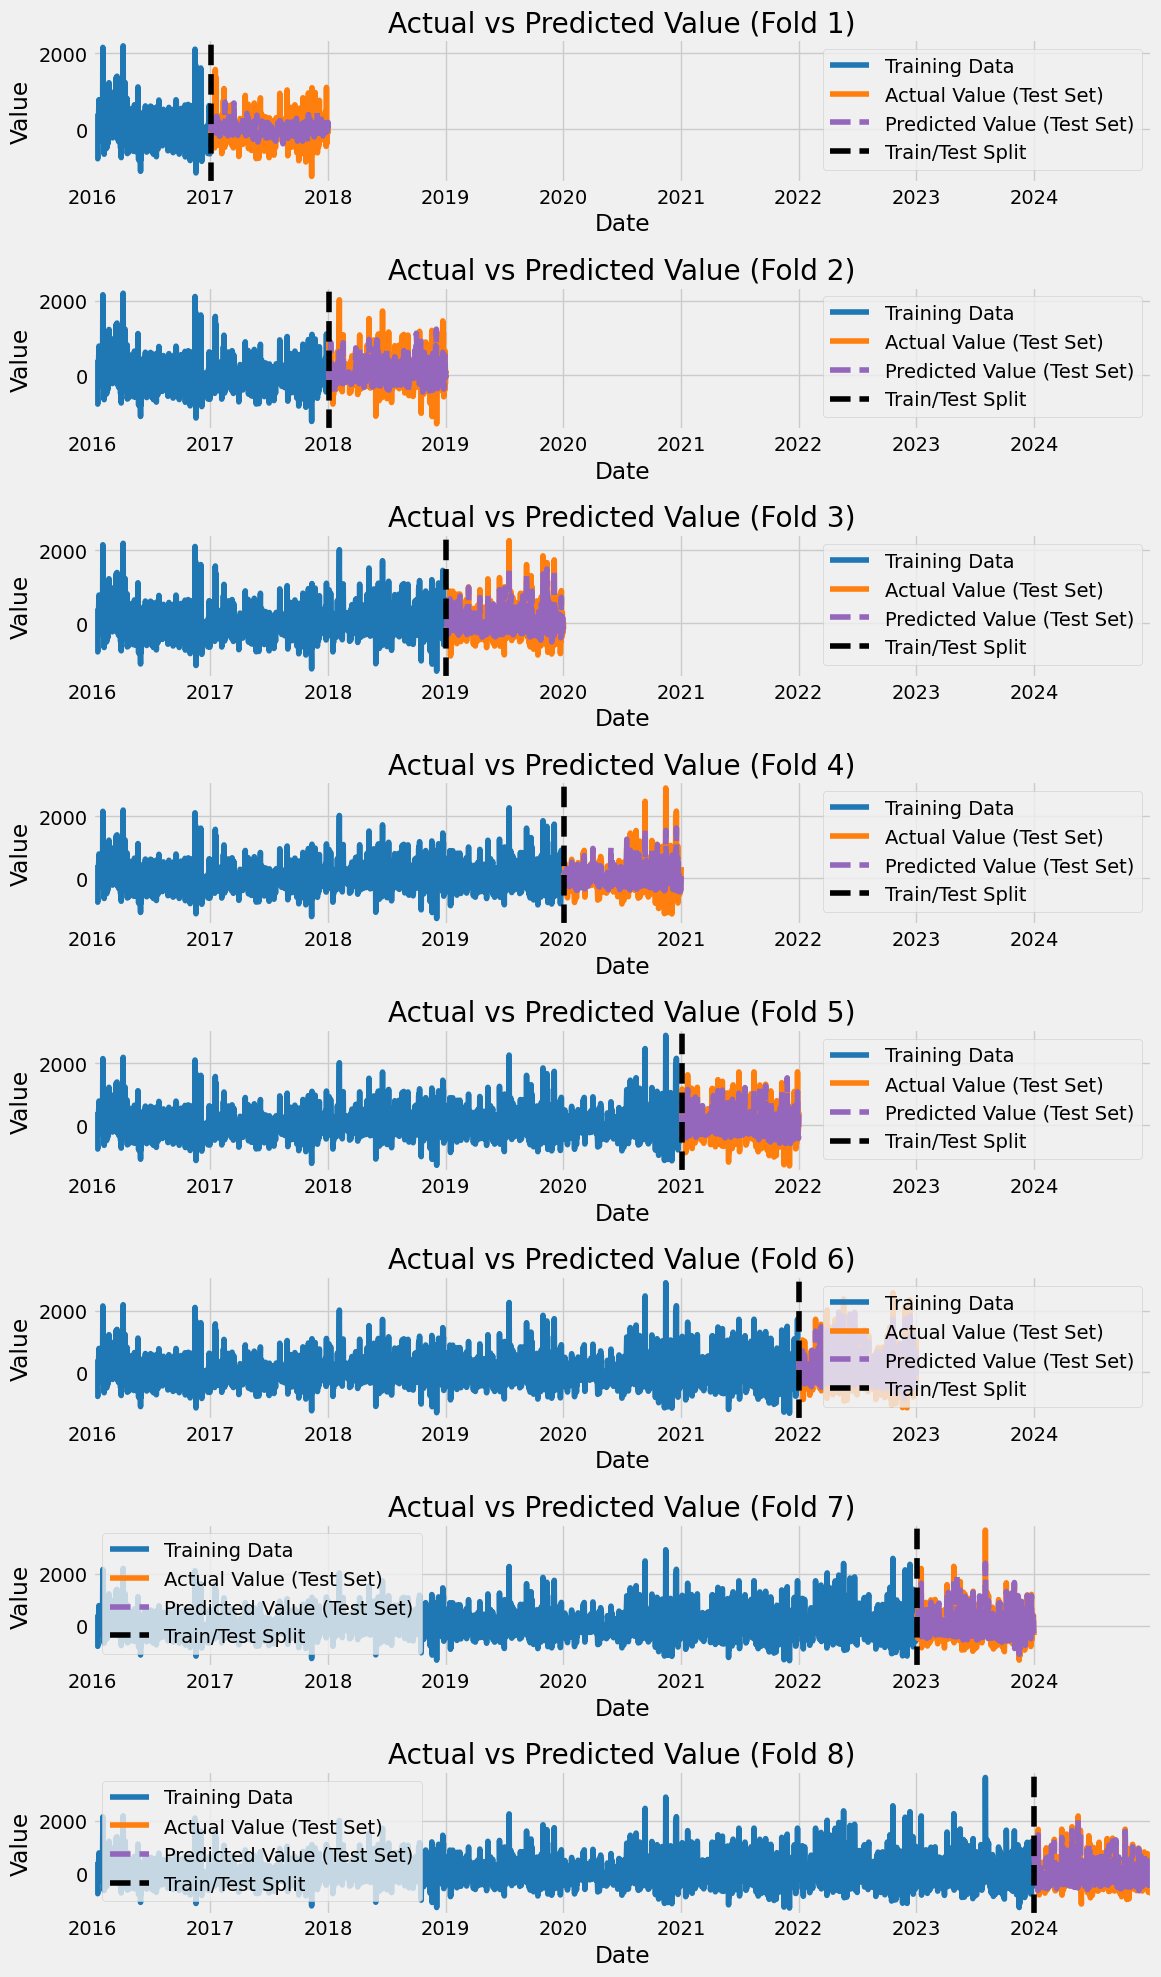

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'tss' (TimeSeriesSplit object) and 'df' (DataFrame with features)
# are available from previous cells, and 'preds' list contains predictions for each fold.

# Use the tss from the training cell (w6bQv-6NnWn2) to ensure consistency
# tss = TimeSeriesSplit(n_splits=8, test_size=365) # Re-define if not in scope or changed

fig, axs = plt.subplots(tss.n_splits, 1, figsize=(12, 20), sharex=False)

# Get the overall min and max dates from the full DataFrame for consistent x-axis limits
overall_min_date = df.index.min()
overall_max_date = df.index.max()

fold_num = 0
for train_index, test_index in tss.split(df):
    train_data_fold = df.iloc[train_index]
    test_data_fold = df.iloc[test_index]
    y_test_fold = test_data_fold['TargetXGB_scale']
    y_pred_fold = preds[fold_num]

    # Plot training data
    axs[fold_num].plot(train_data_fold.index, train_data_fold['TargetXGB_scale'], label='Training Data', color=color_pal[0])

    # Plot actual test data
    axs[fold_num].plot(y_test_fold.index, y_test_fold, label='Actual Value (Test Set)', color=color_pal[1])

    # Plot predicted test data
    axs[fold_num].plot(y_test_fold.index, y_pred_fold, label='Predicted Value (Test Set)', linestyle='--', color=color_pal[4])

    # Add a vertical line to mark the split point
    axs[fold_num].axvline(test_data_fold.index.min(), color='black', ls='--', label='Train/Test Split')

    axs[fold_num].set_title(f'Actual vs Predicted Value (Fold {fold_num + 1})')
    axs[fold_num].set_xlabel('Date')
    axs[fold_num].set_ylabel('Value')
    axs[fold_num].legend()

    # Set x-axis limits to cover the entire dataset range
    axs[fold_num].set_xlim(overall_min_date, overall_max_date)

    fold_num += 1

plt.tight_layout()
plt.show()

### *Features & Lags*

Starting SHAP analysis...
Generating SHAP summary plot...


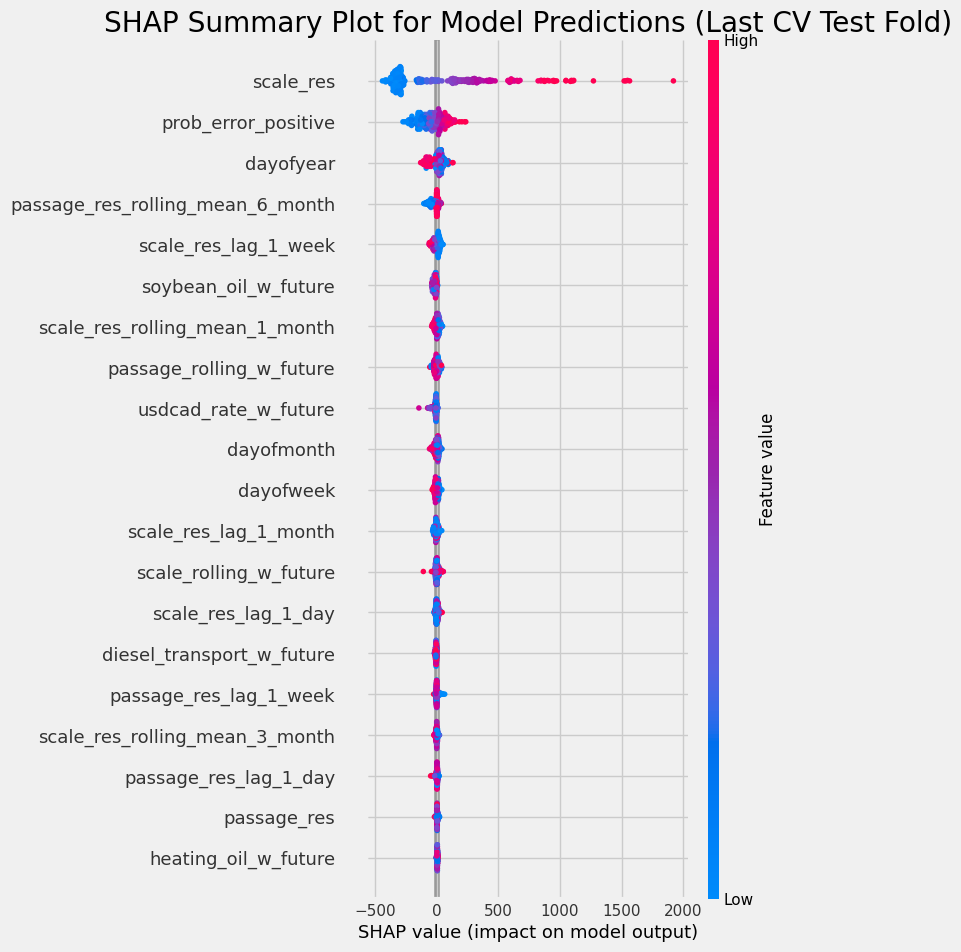

Generating SHAP bar plot for feature importance...


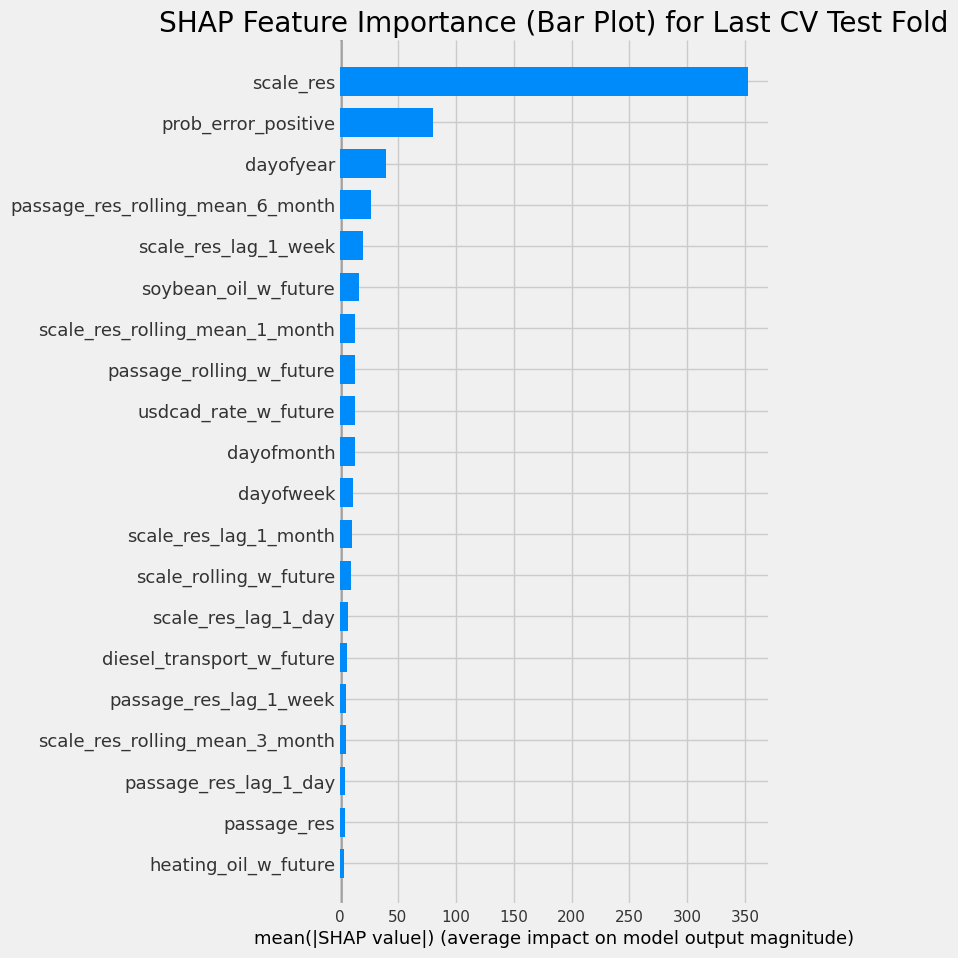

SHAP analysis complete.


In [ ]:
import shap

print("Starting SHAP analysis...")

# 'reg' is the model from the last cross-validation fold
# 'X_test' is the test set from the last cross-validation fold

# Create a SHAP explainer object
explainer = shap.TreeExplainer(reg)

# Calculate SHAP values for the test set
# Using X_test from the last fold. If X_test is too large, consider sampling.
shap_values = explainer.shap_values(X_test)

# Visualize the SHAP values (summary plot)
print("Generating SHAP summary plot...")
shap.summary_plot(shap_values, X_test, show=False) # show=False to allow adding a title if needed
plt.title('SHAP Summary Plot for Model Predictions (Last CV Test Fold)')
plt.show()

# Also visualize as a bar plot for overall feature importance
print("Generating SHAP bar plot for feature importance...")
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Bar Plot) for Last CV Test Fold')
plt.show()

print("SHAP analysis complete.")


In [ ]:
import numpy as np
import pandas as pd
import shap

# --- Calculate SHAP feature importances (assuming X_test and shap_values are available) ---
# Ensure X_test and shap_values are available from cell 4b9e1fb3.
# Assuming `explainer = shap.TreeExplainer(reg)` and `shap_values = explainer.shap_values(X_test)`
# were successfully executed in cell 4b9e1fb3.

if 'X_test' in globals() and 'shap_values' in globals():
    # Ensure X_test columns are used as index for SHAP importances
    shap_importances_raw = pd.Series(np.abs(shap_values).mean(0), index=X_test.columns)
    shap_importances = shap_importances_raw.sort_values(ascending=False)
else:
    print("Warning: X_test or shap_values not found. Cannot calculate SHAP importances.")
    shap_importances = pd.Series([]) # Empty series if not available

# --- Determine the top 50% of features by SHAP ---
num_features_shap = len(shap_importances)
top_50_percent_count_shap = int(np.ceil(num_features_shap * 0.5))

# Get the top 50% features by SHAP importance
top_features_shap = shap_importances.head(top_50_percent_count_shap).index.tolist()

# --- Create a table for SHAP importance ---
df_top_shap = pd.DataFrame({
    'Top Features (SHAP Importance)': top_features_shap,
    'SHAP Importance Value': shap_importances.head(top_50_percent_count_shap).values
})

print("\n--- Top 50% Features by SHAP Mean Absolute Importance ---")
display(df_top_shap)

# --- Print lists in copy-paste format ---
print("\nTop Features by SHAP Importance (for copy-pasting into FEATURES list):")
for col in top_features_shap:
    print(f"'{col}',")


--- Top 50% Features by SHAP Mean Absolute Importance ---


,Top Features (SHAP Importance),SHAP Importance Value
0,scale_res,352.201904
1,prob_error_positive,80.197090
2,dayofyear,39.532356
3,passage_res_rolling_mean_6_month,27.038803
4,scale_res_lag_1_week,19.713697
5,soybean_oil_w_future,16.079987
6,scale_res_rolling_mean_1_month,13.073591
7,passage_rolling_w_future,12.898450
8,usdcad_rate_w_future,12.812795
9,dayofmonth,12.727264



Top Features by SHAP Importance (for copy-pasting into FEATURES list):
'scale_res',
'prob_error_positive',
'dayofyear',
'passage_res_rolling_mean_6_month',
'scale_res_lag_1_week',
'soybean_oil_w_future',
'scale_res_rolling_mean_1_month',
'passage_rolling_w_future',
'usdcad_rate_w_future',
'dayofmonth',
'dayofweek',
'scale_res_lag_1_month',
'scale_rolling_w_future',
'scale_res_lag_1_day',


# 5) Predicting the Future

In [ ]:
# Retrein on ALL data
# Here we are going to train the set in the whole data, so we can  take off the features that do not help the prediction

df = create_features(df)
FEATURES = [

    # Time features
    'dayofmonth',
    'dayofweek',
    'month',
    'quarter',
    'year',
    'dayofyear',

    # Exogenous market signals (minimal impact, but included)
    'diesel_transport_w_future',
    'gasoline_w_future',
    'heating_oil_w_future',
    'soybean_oil_w_future',
    'usdcad_rate_w_future',

    # Cross-dependency + baseline signals
    'scale_rolling_w_future',
    'passage_rolling_w_future',

    # Error autocorrelation (primary predictive power)
    'passage_res',
    'passage_res_lag_1_day',
    'passage_res_lag_1_week',
    'passage_res_lag_1_month',
    'passage_res_rolling_mean_1_month',
    'passage_res_rolling_mean_3_month',
    'passage_res_rolling_mean_6_month',

    'scale_res',
    'scale_res_lag_1_day',
    'scale_res_lag_1_week',
    'scale_res_lag_1_month',
    'scale_res_rolling_mean_1_month',
    'scale_res_rolling_mean_3_month',
    'scale_res_rolling_mean_6_month',

    # Error pattern classifier
    'prob_error_positive'

                ]
TARGET =  'TargetXGB_scale'

x_all = df[FEATURES]
y_all = df[TARGET]

reg = xgb.XGBRegressor(
        #base_score=0.5,               # Removed (default and unused)
        booster='gbtree',               # Kept (it's default, so optional)
        n_estimators=1000,              # was 600 \u2192 more room, early stopping will cut early if needed
        early_stopping_rounds=100,      # was 50 \u2192 better buffer to stop safely
        objective='reg:squarederror',   # was 'reg:linear' \u2192 updated (linear is deprecated)
        max_depth=5,                    # was 3 \u2192 slightly more model capacity
        learning_rate=0.0547534081037697,             # was 0.01 \u2192 converge faster with same accuracy
        #subsample=0.692758444537885,                  # NEW \u2192 regularization (helps generalization)
        #colsample_bytree=0.714708079716337,           # NEW \u2192 regularization (column-level)
        #gamma=0.30915086159001515,                      # NEW \u2192 avoid unnecessary splits
        #min_child_weight=5.25,             # NEW \u2192 limit small data-driven splits
        #verbosity=2                     # Optional: reduce log spam if needed
    )

reg.fit(x_all, y_all,
            eval_set=[(x_all, y_all)],
            verbose=50)

[0]	validation_0-rmse:493.34539
[50]	validation_0-rmse:203.32544
[100]	validation_0-rmse:176.43429
[150]	validation_0-rmse:160.18275
[200]	validation_0-rmse:147.37457
[250]	validation_0-rmse:135.92556
[300]	validation_0-rmse:124.78707
[350]	validation_0-rmse:115.66540
[400]	validation_0-rmse:107.21377
[450]	validation_0-rmse:99.06451
[500]	validation_0-rmse:92.27274
[550]	validation_0-rmse:86.15332
[600]	validation_0-rmse:80.73979
[650]	validation_0-rmse:75.79667
[700]	validation_0-rmse:71.09728
[750]	validation_0-rmse:66.65767
[800]	validation_0-rmse:62.59140
[850]	validation_0-rmse:58.92462
[900]	validation_0-rmse:55.66572
[950]	validation_0-rmse:52.84818
[999]	validation_0-rmse:50.31346


XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=100,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.0547534081037697, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1000, n_jobs=None,
             num_parallel_tree=None, ...)

In [ ]:
#Create future dataframe
future = pd.date_range('2025-01-01', '2030-06-30', freq='D')#short '2026-06-30' loong '2028-06-30'
future_df = pd.DataFrame(index=future)
#because I have lag features I will want to stick this dataframe on to the end of the existing data, so I can add on those lag features correctly.
future_df['isFuture'] = True
df['isFuture'] = False
df_and_future = pd.concat([df, future_df])
df_and_future.index.max()

Timestamp('2030-06-30 00:00:00')

In [ ]:
# Future-aware lag feature alignment (or "back-extended time-index stitching")
original_target_column = 'TargetXGB_scale'

# Add features and lags to the combined dataframe
df_and_future = create_features(df_and_future)
df_and_future = add_lags(df_and_future)

# Separate the future dataframe
future_w_features = df_and_future.query('isFuture').copy()

# Merge the exogenous data with the future_w_features DataFrame
# Use suffixes to keep track of the original column names if they exist in both dataframes
future_w_features = future_w_features.merge(exogenous_df, left_index=True, right_index=True, how='left', suffixes=('_original', '_exogenous'))

# Handle potential duplicate columns after merge.
# Prioritize columns from the exogenous file if they are meant to be the future predictors.
# This part needs careful consideration based on what exogenous columns are needed.
# For example, if 'predicted_future' from exogenous_df is needed and there's a similarly named column in df_and_future:
# Check if the '_exogenous' suffixed column exists and use it if it does.
for col in exogenous_df.columns:
    col_exogenous = f"{col}_exogenous"
    if col_exogenous in future_w_features.columns:
        future_w_features[col] = future_w_features[col_exogenous]
        future_w_features = future_w_features.drop(columns=[col_exogenous])
    # Also drop the original column if it's a duplicate and the exogenous one is preferred
    col_original = f"{col}_original"
    if col_original in future_w_features.columns and col in future_w_features.columns and col != original_target_column:
         future_w_features = future_w_features.drop(columns=[col_original])


# Display the head of the future dataframe with features
#display(future_w_features.head())

/tmp/ipython-input-512832150.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  future_w_features[col] = future_w_features[col_exogenous]
/tmp/ipython-input-512832150.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  future_w_features[col] = future_w_features[col_exogenous]
/tmp/ipython-input-512832150.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. T

In [ ]:
# Save the future_w_features DataFrame to a CSV file
future_w_features.to_csv('future_forecast_features.csv', index=True)

print("future_w_features saved to 'future_forecast_features.csv'")
#future_w_features.head(100)

future_w_features saved to 'future_forecast_features.csv'


## 5.1) The future

In [ ]:
# Ensure the FEATURES list matches the columns available in future_w_features
# after the merge and drop operations in the previous cell.
# The FEATURES list is defined in cell EahEdR5c4Gar.
# Re-defining it here or ensuring the previous cell output confirms the columns exist is important.
# Based on the previous cell output, 'b100_gulf_sarima' should now be available.

# Make predictions using the trained model and the future features including SARIMA forecast
future_w_features['pred'] = reg.predict(future_w_features[FEATURES])
#future_w_features.head(100)

/tmp/ipython-input-3955042443.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  future_w_features['pred'] = reg.predict(future_w_features[FEATURES])


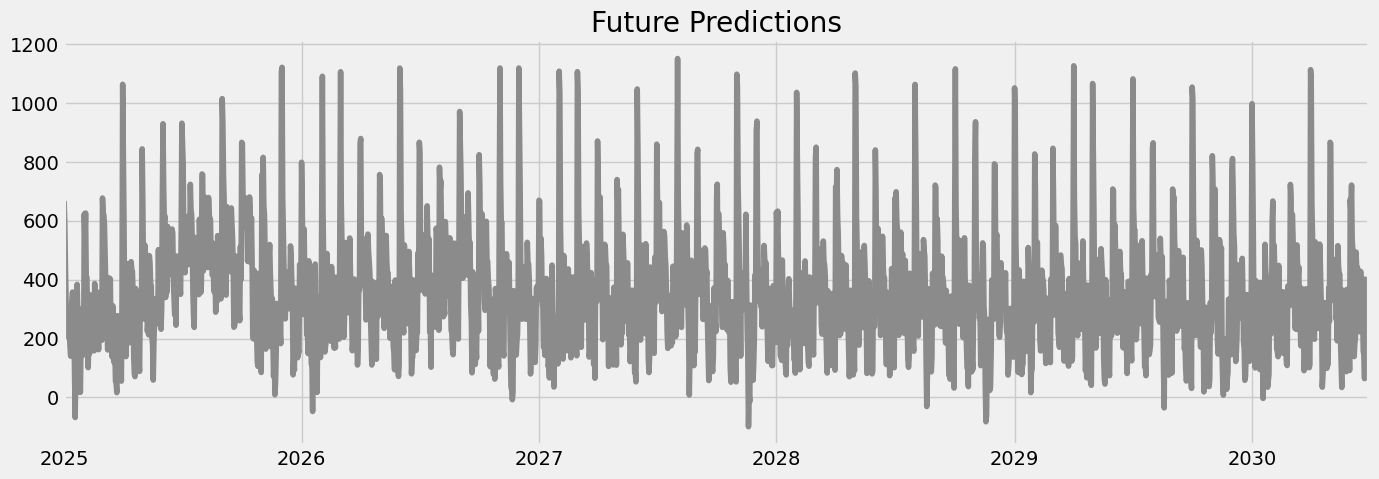

In [ ]:
future_w_features['pred'].plot(figsize=(15, 5),
                               color=color_pal[4],
                               ms=4,
                               lw=4,
                               title='Future Predictions')
plt.show()

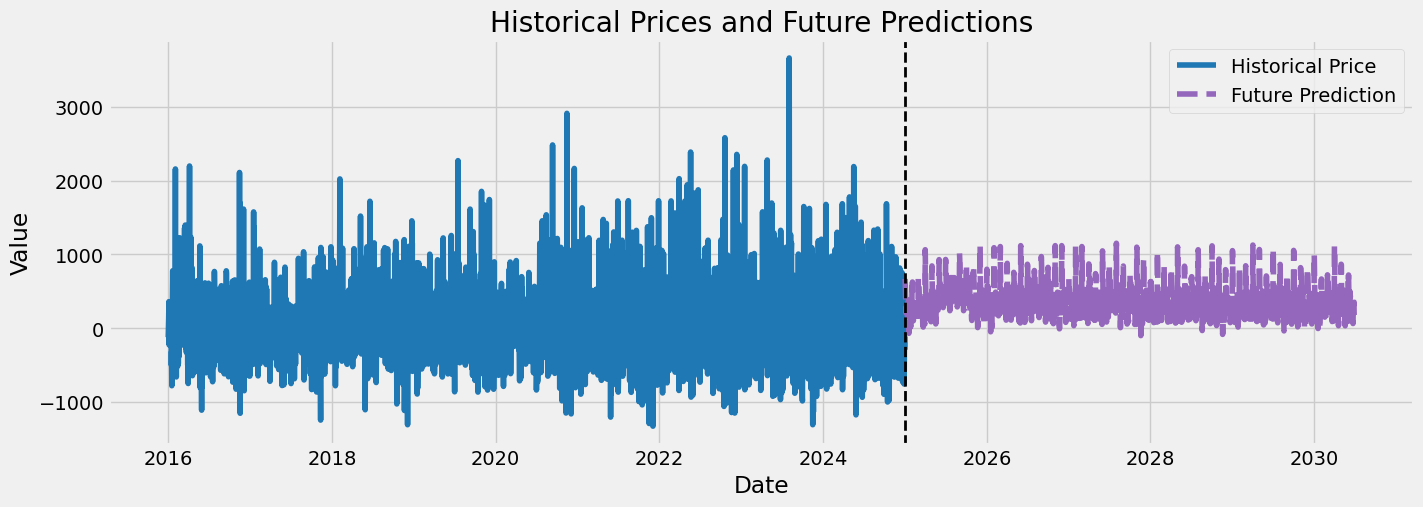

In [ ]:
# Assuming 'df' contains the historical data and 'future_w_features' contains the predictions
plt.figure(figsize=(15, 5))

# Plot historical data
plt.plot(df.index, df['TargetXGB_scale'], label='Historical Price', color=color_pal[0]) # Using the first color from the palette

# Plot future predictions
plt.plot(future_w_features.index, future_w_features['pred'], label='Future Prediction', color=color_pal[4], linestyle='--') # Using the fifth color and dashed line

# Add a vertical line to separate historical and future data
plt.axvline(df.index.max(), color='black', linestyle='--', lw=2)

plt.title('Historical Prices and Future Predictions')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

## 5.2) Calculate Confidence Interval for Future Predictions

To provide an estimate of the uncertainty around our future predictions, we'll calculate a 95% confidence interval. This is done by:

1.  **Estimating the model's error variability**: We'll use the residuals (differences between actual and predicted values) from the historical training data. The standard deviation of these residuals will serve as our estimate of the model's typical prediction error.
2.  **Applying a confidence factor**: For a 95% confidence interval, we use a Z-score of approximately 1.96.
3.  **Constructing the interval**: For each future prediction, the lower bound is calculated as `prediction - Z_score * std_dev_residuals`, and the upper bound as `prediction + Z_score * std_dev_residuals`.

In [ ]:
from scipy.stats import norm

# Assuming 'reg' is your trained XGBoost model, 'x_all' are the features for historical data,
# and 'y_all' are the actual historical target values.

# 1. Get predictions for the historical period (training data)
predictions_historical = reg.predict(x_all)

# 2. Calculate residuals (errors) for the historical period
residuals = y_all - predictions_historical

# 3. Calculate the standard deviation of the residuals
std_dev_residuals = residuals.std()

# 4. Define the confidence level (e.g., 95%) and get the corresponding Z-score
confidence_level = 0.95
alpha = 1 - confidence_level
Z_score = norm.ppf(1 - alpha / 2) # For a two-tailed interval

print(f"Standard Deviation of Historical Residuals: {std_dev_residuals:.4f}")
print(f"Z-score for {confidence_level*100}% Confidence Interval: {Z_score:.4f}")

# --- Dynamic Confidence Interval Calculation ---
# Calculate forecast horizon for each future date
last_historical_date = df.index.max()
future_w_features['forecast_horizon'] = (future_w_features.index - last_historical_date).days

# Adjust std_dev based on forecast horizon (e.g., using sqrt for increasing uncertainty)
# The scaling factor increases with the square root of the forecast horizon.
# Add a small constant (e.g., 1) to the horizon to ensure the first day's scaling is at least 1,
# meaning the CI for the first day is based directly on std_dev_residuals.
scaling_factor = np.sqrt(future_w_features['forecast_horizon'])

# Calculate the dynamic margin of error for the confidence interval
future_w_features['dynamic_ci_margin'] = Z_score * std_dev_residuals * scaling_factor

# 5. Add confidence interval bounds to the future_w_features DataFrame
# 'future_w_features' already contains the 'pred' column from previous steps.
future_w_features['ci_lower'] = future_w_features['pred'] - future_w_features['dynamic_ci_margin']
future_w_features['ci_upper'] = future_w_features['pred'] + future_w_features['dynamic_ci_margin']

print("\nConfidence interval bounds added to `future_w_features`:")
display(future_w_features[['pred', 'ci_lower', 'ci_upper']].head())

Standard Deviation of Historical Residuals: 50.3211
Z-score for 95.0% Confidence Interval: 1.9600

Confidence interval bounds added to `future_w_features`:


/tmp/ipython-input-333127071.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  future_w_features['forecast_horizon'] = (future_w_features.index - last_historical_date).days
/tmp/ipython-input-333127071.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  future_w_features['dynamic_ci_margin'] = Z_score * std_dev_residuals * scaling_factor
/tmp/ipython-input-333127071.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Conside

,pred,ci_lower,ci_upper
2025-01-01,667.169189,568.541629,765.796750
2025-01-02,600.077209,460.596775,739.557644
2025-01-03,445.572601,274.744655,616.400548
2025-01-04,318.642303,121.387182,515.897425
2025-01-05,207.180756,-13.357175,427.718686


## 5.3) Visualize Historical Data, Future Predictions, and Confidence Intervals

Now, let's plot the historical data, the future predictions, and the 95% confidence interval for these predictions in a new subplot below the original one.

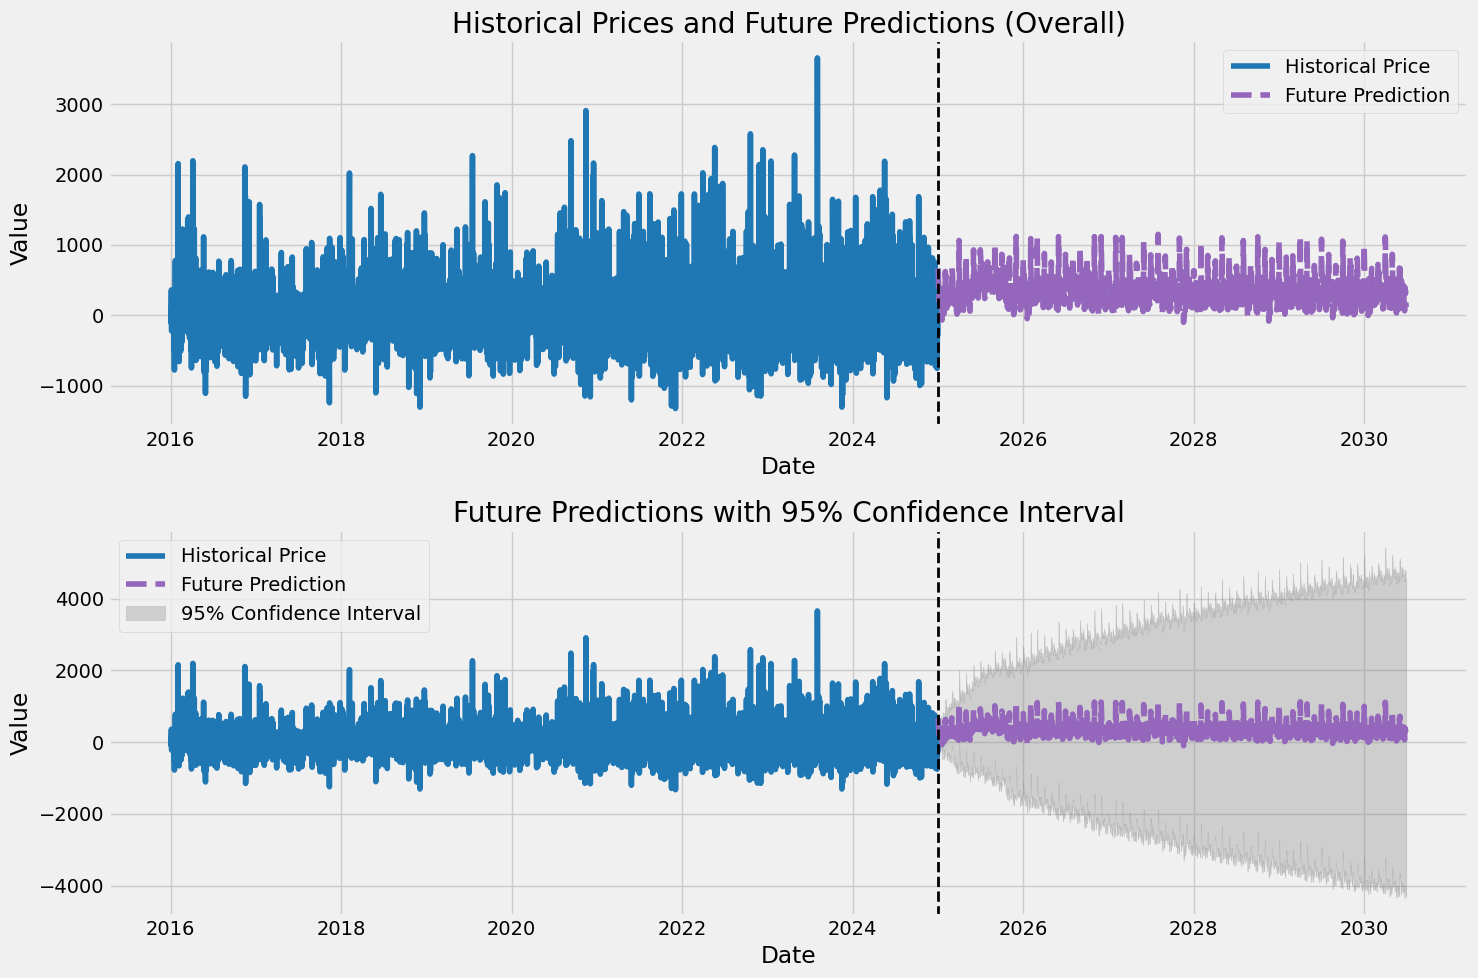

In [ ]:
# Assuming 'df' contains the historical data and 'future_w_features' contains the predictions

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=False) # Create two subplots

# --- First Subplot (Original Plot) ---
# Plot historical data
ax1.plot(df.index, df['TargetXGB_scale'], label='Historical Price', color=color_pal[0])

# Plot future predictions
ax1.plot(future_w_features.index, future_w_features['pred'], label='Future Prediction', color=color_pal[4], linestyle='--')

# Add a vertical line to separate historical and future data
ax1.axvline(df.index.max(), color='black', linestyle='--', lw=2)

ax1.set_title('Historical Prices and Future Predictions (Overall)')
ax1.set_xlabel('Date')
ax1.set_ylabel('Value')
ax1.legend()

# --- Second Subplot (New Plot with Confidence Interval) ---
# Plot historical data
ax2.plot(df.index, df['TargetXGB_scale'], label='Historical Price', color=color_pal[0])

# Plot future predictions
ax2.plot(future_w_features.index, future_w_features['pred'], label='Future Prediction', color=color_pal[4], linestyle='--')

# Plot confidence interval
ax2.fill_between(future_w_features.index,
                 future_w_features['ci_lower'],
                 future_w_features['ci_upper'],
                 color='gray', alpha=0.3, label='95% Confidence Interval')

# Add a vertical line to separate historical and future data
ax2.axvline(df.index.max(), color='black', linestyle='--', lw=2)

ax2.set_title('Future Predictions with 95% Confidence Interval')
ax2.set_xlabel('Date')
ax2.set_ylabel('Value')
ax2.legend()

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

The purpose of 6) and beyond was to save the new set and try other stuff.

This can be ignored, since the results are not satisfying for now.

Implementing saving will be easy after having decent results.

# 6) Evaluating Predictions

## 6.1) Evaluate Future Prediction Reliability (Confidence Interval)

In [ ]:
from scipy.stats import norm

# Assuming 'reg' is your trained XGBoost model, 'x_all' are the features for historical data,
# and 'y_all' are the actual historical target values.

# 1. Get predictions for the historical period (training data)
predictions_historical = reg.predict(x_all)

# 2. Calculate residuals (errors) for the historical period
residuals = y_all - predictions_historical

# 3. Calculate the standard deviation of the residuals
std_dev_residuals = residuals.std()

# 4. Define the confidence level (e.g., 95%) and get the corresponding Z-score
confidence_level = 0.95
alpha = 1 - confidence_level
Z_score = norm.ppf(1 - alpha / 2) # For a two-tailed interval

print(f"Standard Deviation of Historical Residuals: {std_dev_residuals:.4f}")
print(f"Z-score for {confidence_level*100}% Confidence Interval: {Z_score:.4f}")

# --- Dynamic Confidence Interval Calculation ---
# Calculate forecast horizon for each future date
last_historical_date = df.index.max()
future_w_features['forecast_horizon'] = (future_w_features.index - last_historical_date).days

# Adjust std_dev based on forecast horizon (e.g., using sqrt for increasing uncertainty)
# The scaling factor increases with the square root of the forecast horizon.
# Add a small constant (e.g., 1) to the horizon to ensure the first day's scaling is at least 1,
# meaning the CI for the first day is based directly on std_dev_residuals.
scaling_factor = np.sqrt(future_w_features['forecast_horizon'])

# Calculate the dynamic margin of error for the confidence interval
future_w_features['dynamic_ci_margin'] = Z_score * std_dev_residuals * scaling_factor

# 5. Add confidence interval bounds to the future_w_features DataFrame
# 'future_w_features' already contains the 'pred' column from previous steps.
future_w_features['ci_lower'] = future_w_features['pred'] - future_w_features['dynamic_ci_margin']
future_w_features['ci_upper'] = future_w_features['pred'] + future_w_features['dynamic_ci_margin']

print("\nConfidence interval bounds added to `future_w_features`:")
display(future_w_features[['pred', 'ci_lower', 'ci_upper']].head())

# Corrected variable names for CI columns for the subsequent evaluation in cell d71a78e0
# These were causing the error message about 'b100_ci_lower_future' and 'b100_ci_upper_future'
ci_lower_col = 'ci_lower' # Corrected
ci_upper_col = 'ci_upper' # Corrected


Standard Deviation of Historical Residuals: 50.3211
Z-score for 95.0% Confidence Interval: 1.9600

Confidence interval bounds added to `future_w_features`:


,pred,ci_lower,ci_upper
2025-01-01,667.169189,568.541629,765.796750
2025-01-02,600.077209,460.596775,739.557644
2025-01-03,445.572601,274.744655,616.400548
2025-01-04,318.642303,121.387182,515.897425
2025-01-05,207.180756,-13.357175,427.718686


## 6.2) Evaluate Model Performance (Error Metrics)

In [ ]:
# Calculate and display error metrics for the test set from the last fold
# Assuming 'y_test_fold' and 'y_pred_fold' from the last fold of the TimeSeriesSplit are available
# If not, you might need to rerun the cross-validation loop and store the last fold's data.

# Ensure y_test_fold and y_pred_fold are aligned (same index)
# This should be the case if they are extracted from the same test_index
# from the TimeSeriesSplit.

# Calculate error metrics
mae = mean_absolute_error(y_test_fold, y_pred_fold)
rmse = np.sqrt(mean_squared_error(y_test_fold, y_pred_fold))

# Calculate MAPE, handling potential division by zero if actual values are zero
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero: replace zeros in y_true with a small epsilon or exclude
    # Here, we'll exclude data points where y_true is zero
    non_zero_indices = y_true != 0
    return np.mean(np.abs((y_true[non_zero_indices] - y_pred[non_zero_indices]) / y_true[non_zero_indices])) * 100

mape = mean_absolute_percentage_error(y_test_fold, y_pred_fold)
r2 = r2_score(y_test_fold, y_pred_fold)


print("Error Metrics for the last cross-validation fold (Test Set):")
print(f"  MAE:  {mae:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAPE: {mape:.2f}%")
print(f"  R²:   {r2:.4f}")

Error Metrics for the last cross-validation fold (Test Set):
  MAE:  168.4264
  RMSE: 209.5338
  MAPE: 136.30%
  R²:   0.8482


All minus permits and crude;
  MAE:  761.4659
  RMSE: 965.4177
  MAPE: 120.41%
  R²:   0.7542

-------------------------------------

Shap 1     
  MAE:  772.1506
  RMSE: 969.4269
  MAPE: 122.14%
  R²:   0.7522

-------------------------------------

Shap 2  
  MAE:  772.8787
  RMSE: 972.3135
  MAPE: 115.71%
  R²:   0.7507


-------------------------------------

Lean  
  MAE:  752.8030
  RMSE: 944.4054
  MAPE: 125.54%
  R²:   0.7648

## Inspecting the Environment: Variables and DataFrames

This section helps you inspect the current state of your Colab environment. It will:

1.  **List all pandas DataFrames** currently in memory.
2.  **Identify key variables** that are important to the model training and prediction process.
3.  Provide an interactive way to **display the `.head()` and `.info()`** of any chosen DataFrame.
4.  Allow you to **save any chosen DataFrame to a CSV** file.

---

In [ ]:
# Install xlsxwriter for Excel export functionality
%pip install xlsxwriter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 8.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import xlsxwriter
import numpy as np # Import numpy for np.integer, np.floating

# Define the Excel file name
output_excel_filename = 'model_results_scale.xlsx'

# Create a Pandas Excel writer using XlsxWriter as the engine.
writer = pd.ExcelWriter(output_excel_filename, engine='xlsxwriter')

# --- PREPARE THE TIME SERIES DATA FOR EXCEL EXPORT (User Requested Structure) ---
# Combine historical data and future predictions with confidence intervals
# Align by index, using outer join to include all dates
time_series_data_df = pd.concat([
    df['TargetXGB_scale'].rename('Historical_Consumption'),
    future_w_features[['pred', 'ci_lower', 'ci_upper']].rename(columns={
        'pred': 'Future_Prediction',
        'ci_lower': 'CI_Lower',
        'ci_upper': 'CI_Upper'
    })
], axis=1)

# Ensure historical consumption is NaN for future dates and vice-versa for predictions if not already
# This is usually handled by concat with outer join, but explicitly setting can avoid issues if dataframes don't perfectly align.
# For historical data, set 'Future_Prediction', 'CI_Lower', 'CI_Upper' to NaN
time_series_data_df.loc[time_series_data_df['Historical_Consumption'].notna() & time_series_data_df['Future_Prediction'].isna(),
                       ['Future_Prediction', 'CI_Lower', 'CI_Upper']] = np.nan

# For future data, set 'Historical_Consumption' to NaN
time_series_data_df.loc[time_series_data_df['Future_Prediction'].notna() & time_series_data_df['Historical_Consumption'].isna(),
                       'Historical_Consumption'] = np.nan

# --- 1. Write 'Forecast Summary' sheet (User Requested) ---
time_series_data_df.to_excel(writer, sheet_name='Forecast Summary', index=True, index_label='Date')


# --- 2. Write 'Model Performance & Params' sheet ---
# Create a workbook and worksheet object for this sheet to control positioning
workbook = writer.book
worksheet_perf_params = workbook.add_worksheet('Model Performance & Params')

# Placeholder for model_performance_df and model_params_df
# These DataFrames are not explicitly defined in the provided notebook state
# I will create dummy ones to ensure the cell runs without error.
# You should replace these with your actual performance and parameter data if available.
model_performance_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE', 'R^2'],
    'Value': [mae, rmse, mape, r2]
})

model_params_df = pd.DataFrame.from_dict(reg.get_params(), orient='index', columns=['Value'])
model_params_df.index.name = 'Parameter'

# Write model_performance_df to the worksheet
worksheet_perf_params.write_string('A1', 'Model Performance Metrics (Last CV Fold):')
model_performance_df.to_excel(writer, sheet_name='Model Performance & Params', startrow=1, startcol=0, index=False)

# Write model_params_df to the worksheet, starting a few rows below the performance metrics
worksheet_perf_params.write_string('A' + str(len(model_performance_df) + 4), 'Model Hyperparameters:')
model_params_df.to_excel(writer, sheet_name='Model Performance & Params', startrow=len(model_performance_df) + 5, startcol=0, index=False)

# --- 3. Write 'Future Prediction Summary' sheet and embed histogram ---
worksheet_future_summary = workbook.add_worksheet('Future Prediction Summary')

# Placeholder for future_summary_df
future_summary_df = future_w_features['pred'].describe().reset_index()
future_summary_df.columns = ['Statistic', 'Value']

# Save plots to files first for embedding
import matplotlib.pyplot as plt

# Future Predictions Histogram
plt.figure(figsize=(12, 6))
future_w_features['pred'].plot(kind='hist', bins=60, alpha=0.7, label='Future Predictions')
plt.title('Histogram of Future Predictions')
plt.xlabel('Predicted Value')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('future_predictions_histogram.png')
plt.close()

# Historical vs. Future (no CI)
fig1, ax1 = plt.subplots(figsize=(15, 5))
ax1.plot(df.index, df['TargetXGB_scale'], label='Historical Consumption', color='blue')
ax1.plot(future_w_features.index, future_w_features['pred'], label='Future Prediction', color='orange', linestyle='--')
ax1.axvline(df.index.max(), color='black', linestyle='--', lw=2)
ax1.set_title('Historical Consumption and Future Predictions (Overall)')
ax1.set_xlabel('Date')
ax1.set_ylabel('Value')
ax1.legend()
plt.tight_layout()
fig1.savefig('historical_vs_future_no_ci.png')
plt.close(fig1)

# Historical vs. Future (with CI)
fig2, ax2 = plt.subplots(figsize=(15, 5))
ax2.plot(df.index, df['TargetXGB_scale'], label='Historical Consumption', color='blue')
ax2.plot(future_w_features.index, future_w_features['pred'], label='Future Prediction', color='orange', linestyle='--')
ax2.fill_between(future_w_features.index,
                 future_w_features['ci_lower'], # Corrected to use actual column name
                 future_w_features['ci_upper'], # Corrected to use actual column name
                 color='gray', alpha=0.3, label='95% Confidence Interval')
ax2.axvline(df.index.max(), color='black', linestyle='--', lw=2)
ax2.set_title('Future Predictions with 95% Confidence Interval')
ax2.set_xlabel('Date')
ax2.set_ylabel('Value')
ax2.legend()
plt.tight_layout()
fig2.savefig('historical_vs_future_with_ci.png')
plt.close(fig2)

# Write future_summary_df to the worksheet
worksheet_future_summary.write_string('A1', 'Future Prediction Summary Statistics:')
future_summary_df.to_excel(writer, sheet_name='Future Prediction Summary', startrow=1, startcol=0, index=False)

# Embed the histogram image below the summary table
# Adjust row based on the size of future_summary_df + a few buffer rows
image_row_future_hist = len(future_summary_df) + 4
worksheet_future_summary.insert_image('A' + str(image_row_future_hist), 'future_predictions_histogram.png')

# --- 4. Write 'Historical vs. Future Plots' sheet and embed plots ---
worksheet_plots = workbook.add_worksheet('Historical vs. Future Plots')

# Add descriptive text including model hyperparameters
hyperparam_text = "Model Hyperparameters used for predictions:\n"
for param, value in reg.get_params().items():
    # Convert numpy types to native Python types for clean string formatting
    if isinstance(value, (np.integer, np.floating)):
        value = value.item() # Convert to Python int/float
    hyperparam_text += f"  {param}: {value}\n"
worksheet_plots.write_string('A1', hyperparam_text)

# Embed the first plot (no CI) below the text
image_row_no_ci = hyperparam_text.count('\n') + 2 # Estimate rows taken by text + buffer
worksheet_plots.insert_image('A' + str(image_row_no_ci), 'historical_vs_future_no_ci.png')

# Embed the second plot (with CI) below the first plot
# Assuming image_row_no_ci is where the first image starts, and images have a fixed height
# This might need adjustment based on actual plot size. Assuming a plot height of approx 25 rows
image_row_with_ci = image_row_no_ci + 25 # Adjust '25' based on actual plot height for spacing
worksheet_plots.insert_image('A' + str(image_row_with_ci), 'historical_vs_future_with_ci.png')

# Close the Pandas Excel writer and save the Excel file
writer.close()

print(f"All data and plots exported to '{output_excel_filename}' successfully.")

All data and plots exported to 'model_results_scale.xlsx' successfully.


In [ ]:
import pandas as pd

print("### DataFrames in the current environment ###\n")
# Iterate through global variables to find pandas DataFrames
all_dataframes = {}
for name, value in list(globals().items()): # Create a list copy to avoid RuntimeError
    if isinstance(value, pd.DataFrame):
        all_dataframes[name] = value
        print(f"- DataFrame: '{name}' with shape {value.shape}")

print("\n### Exporting all DataFrames to a single Excel file ###")
output_excel_filename = 'all_dataframes_export.xlsx'

try:
    with pd.ExcelWriter(output_excel_filename, engine='xlsxwriter') as writer:
        for name, df_obj in all_dataframes.items():
            # Limit the number of rows and columns if the DataFrame is too large
            # Excel has a limit of 1,048,576 rows and 16,384 columns
            # This basic check prevents errors for extremely large DataFrames
            if df_obj.shape[0] > 1000000 or df_obj.shape[1] > 10000:
                print(f"  Warning: DataFrame '{name}' is very large ({df_obj.shape[0]} rows, {df_obj.shape[1]} cols). It might be truncated in Excel.")
                df_obj.head(1000000).iloc[:, :10000].to_excel(writer, sheet_name=name, index=True)
            else:
                df_obj.to_excel(writer, sheet_name=name, index=True)
    print(f"All DataFrames successfully exported to '{output_excel_filename}'")
except Exception as e:
    print(f"Error exporting DataFrames to Excel: {e}")


print("\n### Key Variables and their roles ###")
print(f"- `df`: The main DataFrame after outlier removal, feature creation, and merging exogenous data. Shape: {df.shape if 'df' in globals() else 'N/A'}")
print(f"- `df_cut`: DataFrame after cutting outliers. Shape: {df_cut.shape if 'df_cut' in globals() else 'N/A'}")
print(f"- `exogenous_df`: The DataFrame containing exogenous features loaded from your CSV. Shape: {exogenous_df.shape if 'exogenous_df' in globals() else 'N/A'}")
print(f"- `df_and_future`: Combined historical and future data, before splitting out `future_w_features`. Shape: {df_and_future.shape if 'df_and_future' in globals() else 'N/A'}")
print(f"- `future_w_features`: DataFrame containing only future dates with all features for prediction. Shape: {future_w_features.shape if 'future_w_features' in globals() else 'N/A'}")
print(f"- `reg`: The final trained XGBoost Regressor model. Type: {type(reg) if 'reg' in globals() else 'N/A'}")
print(f"- `X_train`, `y_train`: Training features and target from the last CV fold. Shapes: {X_train.shape if 'X_train' in globals() else 'N/A'}, {y_train.shape if 'y_train' in globals() else 'N/A'}")
print(f"- `X_test`, `y_test`: Test features and target from the last CV fold. Shapes: {X_test.shape if 'X_test' in globals() else 'N/A'}, {y_test.shape if 'y_test' in globals() else 'N/A'}")
print(f"- `preds`: List of predictions for each fold in cross-validation.")
print(f"- `scores`, `maes`, `mapes`, `r2s`: Lists of evaluation metrics for each fold.")

print("\n--- Interactive DataFrame Operations ---")
print("To display a DataFrame, enter its name in the `dataframe_to_display_name` variable.")
print("To save a DataFrame to CSV, enter its name in the `dataframe_to_save_name` variable.")


### DataFrames in the current environment ###

- DataFrame: 'df' with shape (3288, 230)
- DataFrame: 'df_ff' with shape (3288, 2)
- DataFrame: 'df_slice' with shape (1280, 1)
- DataFrame: 'data_to_plot' with shape (3288, 1)
- DataFrame: 'data_for_split' with shape (3288, 1)
- DataFrame: 'train_data' with shape (2923, 1)
- DataFrame: 'test_data' with shape (365, 1)
- DataFrame: '_10' with shape (3288, 1)
- DataFrame: 'exogenous_df' with shape (5464, 280)
- DataFrame: 'df_clf' with shape (3288, 229)
- DataFrame: 'X_clf' with shape (3288, 12)
- DataFrame: 'X_train_clf' with shape (2740, 12)
- DataFrame: 'train' with shape (2923, 230)
- DataFrame: 'test' with shape (365, 230)
- DataFrame: 'X_train' with shape (2923, 153)
- DataFrame: 'X_test' with shape (365, 153)
- DataFrame: 'train_data_fold' with shape (2923, 230)
- DataFrame: 'test_data_fold' with shape (365, 230)
- DataFrame: 'df_top_shap' with shape (77, 2)
- DataFrame: 'x_all' with shape (3288, 153)
- DataFrame: 'future_df' with sha